# The FSC and GRU pipeline: fit both, line them up, understand the GRU
### A win-stay / lose-shift worked example

Two families of minimal, interpretable decision model are fit to the same behavior and compared:

1. A **finite-state controller (FSC)**: a small discrete-memory controller, fit by MAPSO and
   selected by held-out loss (section 2).
2. A **GRU**: the smallest recurrent network that explains the behavior, trained by cross-validation
   over hidden size (section 3).

The pipeline runs end to end and answers two questions:

- **Does the GRU learn the policy?** On held-out sessions, does it match the FSC on predictive
  likelihood and on the action-transition matrix (section 4)?
- **Is it the same machine as the FSC?** We solve for the exact GRU whose weights *are* the
  controller, then measure how close the trained GRU gets and, most of the notebook's weight,
  **why it does not get all the way** (section 5), before checking that the two internal states still
  line up (section 6).

Everything is driven by one `DATASET` variable in section 0: change it and rerun to regenerate every
figure for another task. The shipped datasets are two win-stay/lose-shift variants (`random_init`,
`det_init`, differing only in the starting state) and a harder 3-state task (`ts`).

## 0. Setup

One config block, then the machinery: a plain-numpy GRU step, the dataset and FSC loaders, and the
plotting style. Nothing task-specific is hard-coded below the config block.

In [1]:
# --- 0.0 config: the whole pipeline is steered from here -------------------------------------
DATASET = "random_init"      # "random_init" | "det_init" | "ts"  -- change this and rerun to retarget
# Per dataset: the .npz, the hidden sizes to sweep, and the size the figures/investigation lead with.
# ts needs a 3-state controller, so it sweeps H=1,2,3 and leads with H=2 (H=1 cannot be a 3-state machine).
_CFG = {
    "random_init": dict(file="datasets/wsls_actions_observations_random_init.npz", h_list=[1, 2],    h_star=1),
    "det_init":    dict(file="datasets/wsls_actions_observations_det_init.npz",    h_list=[1, 2],    h_star=1),
    "ts":          dict(file="datasets/ts_actions_observations.npz",               h_list=[1, 2, 3], h_star=1),
}
DATASET_FILE  = _CFG[DATASET]["file"]
H_LIST        = _CFG[DATASET]["h_list"]
H_STAR        = _CFG[DATASET]["h_star"]
L1_WEIGHT     = 0.0        # L1 penalty on the recurrent weights; 0 here (section 5 shows why it matters)
TEST_FRAC     = 0.2        # held-out fraction for the generalization claim in section 4
SPLIT_SEED    = 0          # the train/test split is deterministic and reproduced by section 3
FORCE_RETRAIN = False      # True wipes this L1 value's fits and retrains from scratch
KMAX          = 80         # length of the off-manifold probe in section 5

In [2]:
# --- 0.1 imports, path switching, a pure-numpy GRU, and the loaders --------------------------
import sys, os, glob, pickle, shutil, subprocess, time
import numpy as np
import joblib
import matplotlib.pyplot as plt
import torch
from torch.func import jacrev
from scipy.optimize import least_squares
from contextlib import contextmanager

torch.set_default_dtype(torch.float64)      # the solver in section 5 works to ~1e-10; float32 cannot

# pandas pickle compat across versions (the fitted FSC was pickled by an older pandas)
import pandas.core.arrays.string_ as _pd_str
from pandas.core.arrays._mixins import NDArrayBacked as _NDArrayBacked
def _compat_string_setstate(self, state):
    if isinstance(state, tuple) and len(state) == 2 and isinstance(state[1], np.ndarray):
        state = (state[0], state[1], {})
    return _NDArrayBacked.__setstate__(self, state)
_pd_str.StringArray.__setstate__ = _compat_string_setstate

REPO         = os.path.abspath(".")
FSC_SRC      = os.path.abspath("FSC-inference-MAPSO/src")
TINYRNN_ROOT = os.path.abspath("tinyRNN")
_COLLIDING   = ("utils", "FSC", "MAPSO", "parametrizations", "environments", "DiscreteObs")

def _use_fsc_path():
    """The two upstream repos ship colliding top-level module names, so only one can sit on
    sys.path at a time. Call the matching switch before importing from either side."""
    if TINYRNN_ROOT in sys.path: sys.path.remove(TINYRNN_ROOT)
    if FSC_SRC not in sys.path:  sys.path.insert(0, FSC_SRC)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

def _use_tinyrnn_path():
    if FSC_SRC in sys.path:          sys.path.remove(FSC_SRC)
    if TINYRNN_ROOT not in sys.path: sys.path.insert(0, TINYRNN_ROOT)
    for m in list(sys.modules):
        if m.split(".")[0] in _COLLIDING: del sys.modules[m]

@contextmanager
def quiet_blas():
    """Apple's Accelerate BLAS raises spurious divide/overflow warnings inside lstsq/svd on
    perfectly finite inputs. Silence just those."""
    old = np.seterr(all="ignore")
    try: yield
    finally: np.seterr(**old)

# ---- one GRU step in numpy, with the three gates exposed (matches torch nn.GRU) -------------
def _sigmoid(x): return np.where(x >= 0, 1.0 / (1.0 + np.exp(-np.abs(x))),
                                 np.exp(-np.abs(x)) / (1.0 + np.exp(-np.abs(x))))
def _softmax(z):
    z = np.asarray(z, float); z = z - z.max(); e = np.exp(z); return e / e.sum()

def gru_step(h, x, P):
    """h' = (1-z)*n + z*h.  z~1 holds h, z~0 overwrites it. Returns (h', {reset, update, new})."""
    H  = P["H"]
    gi = P["W_ih"] @ x + P["b_ih"]
    gh = P["W_hh"] @ h + P["b_hh"]
    r  = _sigmoid(gi[:H]    + gh[:H])
    z  = _sigmoid(gi[H:2*H] + gh[H:2*H])
    n  = np.tanh( gi[2*H:]  + r * gh[2*H:])
    return (1 - z) * n + z * h, {"reset": r, "update": z, "new": n}

def rnn_action_probs(h, P): return _softmax(h @ P["lin_W"].T + P["lin_b"])
def encode_input(a, y, A, Y):
    x = np.zeros(A + Y); x[a] = 1.0; x[A + y] = 1.0; return x
def gates_at(P, h, a, y): return gru_step(h, encode_input(a, y, A, Y), P)

def rnn_states(P, actions, observations, A, Y):
    """Teacher-forced hidden trajectory. h[t] is the state the readout saw when it had to predict
    actions[t]; there are T+1 rows, matching the FSC belief filter below."""
    h = np.zeros(P["H"]); out = [h.copy()]
    for t in range(len(actions)):
        h, _ = gru_step(h, encode_input(actions[t], observations[t], A, Y), P)
        out.append(h.copy())
    return np.array(out)

# ---- loaders --------------------------------------------------------------------------------
def load_dataset(path):
    """Integer-encode every session once so the FSC and the RNN see identical trials."""
    raw = np.load(os.path.join(REPO, path))
    ra, ro = raw["actions"], raw["observations"]
    ActSpace = np.array(sorted(set(ra.flatten().tolist())))
    ObsSpace = np.array(sorted(set(ro.flatten().tolist())))
    a2i = {v: i for i, v in enumerate(ActSpace)}
    o2i = {v: i for i, v in enumerate(ObsSpace)}
    sessions = [{"actions":      np.array([a2i[a] for a in ra[i]], dtype=int),
                 "observations": np.array([o2i[o] for o in ro[i]], dtype=int)}
                for i in range(ra.shape[0])]
    win_idx = int(np.where(ObsSpace == 1)[0][0]) if 1 in ObsSpace.tolist() else len(ObsSpace) - 1
    return dict(ActSpace=ActSpace, ObsSpace=ObsSpace, A=len(ActSpace), Y=len(ObsSpace),
                win_idx=win_idx, lose_idx=1 - win_idx, sessions=sessions)

def split_sessions(sessions, seed=SPLIT_SEED, test_frac=TEST_FRAC):
    """Deterministic train/test split. Section 3 writes exactly this train set to disk for the
    trainer, so the fits and the held-out evaluation stay consistent."""
    n = len(sessions); perm = np.random.default_rng(seed).permutation(n)
    n_test = int(round(test_frac * n))
    test  = [sessions[i] for i in perm[:n_test]]
    train = [sessions[i] for i in perm[n_test:]]
    return train, test

def extract_gru_params(agent):
    net = agent.model
    p = {k: v.detach().cpu().numpy() for k, v in net.rnn.named_parameters()}
    return {"W_ih": p["weight_ih_l0"], "W_hh": p["weight_hh_l0"],
            "b_ih": p["bias_ih_l0"],   "b_hh": p["bias_hh_l0"],
            "lin_W": net.lin.weight.detach().cpu().numpy(),
            "lin_b": net.lin.bias.detach().cpu().numpy(), "H": net.hidden_dim}

def load_trained_rnns(exp_folder, A, Y, h_list):
    """Load the best trained GRU (lowest trainval loss) at each hidden size from one experiment."""
    _use_tinyrnn_path()
    live = f"files/saved_model/{exp_folder}"
    arch = os.path.join(REPO, "fitted_models", DATASET, "rnn", exp_folder)
    cwd = os.getcwd(); os.chdir("tinyRNN")
    try:
        if os.path.isdir(arch) and not os.path.isdir(live): shutil.copytree(arch, live)
        from agents import Agent
        from analyzing_experiments.analyzing_perf import select_final_rnn_perf
        _, summary, _ = select_final_rnn_perf(exp_folder, return_dim_est=True, verbose=False)
        out = {}
        for H in h_list:
            rows = summary[summary["hidden_dim"] == H].sort_values("trainval_loss")
            if len(rows) == 0: continue
            cfg = {"agent_type": "RNN", "rnn_type": "GRU", "input_dim": A + Y, "hidden_dim": H,
                   "output_dim": A, "device": "cpu", "output_h0": True, "trainable_h0": False,
                   "readout_FC": True, "one_hot": False, "seed": 0}
            ag = Agent("RNN", config=cfg); ag.load(str(rows.iloc[0]["model_path"]))
            out[H] = extract_gru_params(ag)
        return out
    finally:
        os.chdir(cwd)

def load_fsc_machine(name):
    """The fitted FSC read off as a machine: pi(a|m), g(m'|y,a,m), rho(m), and its joint TMat."""
    _use_fsc_path()
    path = glob.glob(os.path.join(REPO, f"fitted_models/{name}/fsc/best_fsc_M*.pkl"))[0]
    with open(path, "rb") as f: fsc = pickle.load(f)
    fsc.set_mode("generation")
    pi  = np.asarray(fsc.get_action_policy())        # (M, A)
    g   = np.asarray(fsc.get_memory_transitions())   # (Y, A, M, M)
    rho = np.asarray(fsc.get_rho())                  # (M,)
    Tm  = np.asarray(fsc.get_TMat())                 # (Y, M, M, A)
    err = np.abs(Tm - pi[None, :, None, :] * np.transpose(g, (0, 2, 3, 1))).max()
    assert err < 1e-9, f"pi * g does not reproduce TMat (max err {err:.2e})"
    return dict(fsc=fsc, M=int(fsc.M), pi=pi, g=g, rho=rho, TMat=Tm)

def fsc_beliefs(FSC, actions, observations):
    """Forward filter b_t(m) = P(memory = m | history up to t). b[0] = rho; T+1 rows, matching
    rnn_states, so b[t] is the belief the FSC held when it had to choose actions[t]."""
    Tm, rho, M = FSC["TMat"], FSC["rho"], FSC["M"]
    b = rho.copy(); out = [b.copy()]
    for t in range(len(actions)):
        bn = b @ Tm[int(observations[t]), :, :, int(actions[t])]
        s = bn.sum()
        b = bn / s if s > 0 else np.ones(M) / M
        out.append(b.copy())
    return np.array(out)

In [3]:
# --- 0.2 load the data and the FSC, set the plot style ---------------------------------------
D    = load_dataset(DATASET_FILE)
A, Y = D["A"], D["Y"]
WIN, LOSE = D["win_idx"], D["lose_idx"]
SESS = D["sessions"]
TRAIN_SESS, TEST_SESS = split_sessions(SESS)

FSC  = load_fsc_machine(DATASET)
M    = FSC["M"]
pi, g, rho = FSC["pi"], FSC["g"], FSC["rho"]

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False,
})
C_FSC, C_SOLVED, C_TRAINED = "#111111", "#1baf7a", "#eb6834"
C_RULE, SHADE = "0.35", "#8a8a86"
C_STATE = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a", 3: "#a35bd1"}
ACT_NAME = {i: f"a={D['ActSpace'][i]:+d}" for i in range(A)}
OBS_NAME = {WIN: "win", LOSE: "lose"}

_runs = []
for s in SESS:
    r = 0
    for v in s["observations"]:
        r = r + 1 if v == WIN else 0
        _runs.append(r)
MAX_STREAK = int(max(_runs))

def shade_indata(ax, label=True):
    ax.axvspan(0, MAX_STREAK, color=SHADE, alpha=0.13, lw=0, zorder=0)
    if label:
        ax.text(MAX_STREAK, 0.02, f" longest streak\n in data (k={MAX_STREAK})", fontsize=7.5,
                color="0.4", ha="left", va="bottom", transform=ax.get_xaxis_transform())

print(f"dataset '{DATASET}': {len(SESS)} sessions x {len(SESS[0]['actions'])} trials")
print(f"  actions {D['ActSpace'].tolist()} -> indices 0..{A-1};  observations {D['ObsSpace'].tolist()}"
      f"  ->  win = index {WIN}, lose = index {LOSE}")
print(f"  split: {len(TRAIN_SESS)} train, {len(TEST_SESS)} test (seed {SPLIT_SEED})")
print(f"  fitted FSC has M = {M} memory states;  longest win streak in the data: {MAX_STREAK}")

dataset 'random_init': 1000 sessions x 200 trials
  actions [-1, 1] -> indices 0..1;  observations [0, 1]  ->  win = index 1, lose = index 0
  split: 800 train, 200 test (seed 0)
  fitted FSC has M = 2 memory states;  longest win streak in the data: 28


## 1. The task

Each trial is one choice of two arms and one outcome, win or lose. The generating rule is
win-stay / lose-shift: keep the arm that just won, switch after a loss, so one bit of memory follows
it perfectly. Section 0 already loaded the sessions, integer-encoded them, and split off a held-out
test set. The two rates below are the whole task in two numbers.

In [4]:
# --- 1.1 the two rule rates, straight off the raw choices ------------------------------------
stay_win = shift_lose = n_win = n_lose = 0
for s in SESS:
    a, o = s["actions"], s["observations"]
    for t in range(1, len(a)):
        if o[t-1] == WIN:  n_win  += 1; stay_win   += int(a[t] == a[t-1])
        else:              n_lose += 1; shift_lose += int(a[t] != a[t-1])
print(f"Measured on all {len(SESS)} sessions ({len(SESS[0]['actions'])} trials each):")
print(f"   P(stay | previous win)   = {stay_win / n_win:.4f}")
print(f"   P(shift | previous lose) = {shift_lose / n_lose:.4f}")
print(f"   longest win streak anywhere in the data: {MAX_STREAK} trials")
print("Both rates sit within a hair of 1.0, so the behavior is deterministic WSLS.")

Measured on all 1000 sessions (200 trials each):
   P(stay | previous win)   = 1.0000
   P(shift | previous lose) = 1.0000
   longest win streak anywhere in the data: 28 trials
Both rates sit within a hair of 1.0, so the behavior is deterministic WSLS.


## 2. The finite-state controller (fitted and selected)

The FSC is the reference the GRU is measured against, and it is a *fitted* model, not a given. It is
a small discrete-memory controller: each memory state plays one fixed action, and a lookup table says
which state to move to after an (action, outcome). It is fit by MAPSO for each candidate number of
states M, and M is selected by held-out loss. Section 2.1 shows that selection, 2.2 reads the selected
controller off as a machine, and 2.3 draws it as a state diagram.

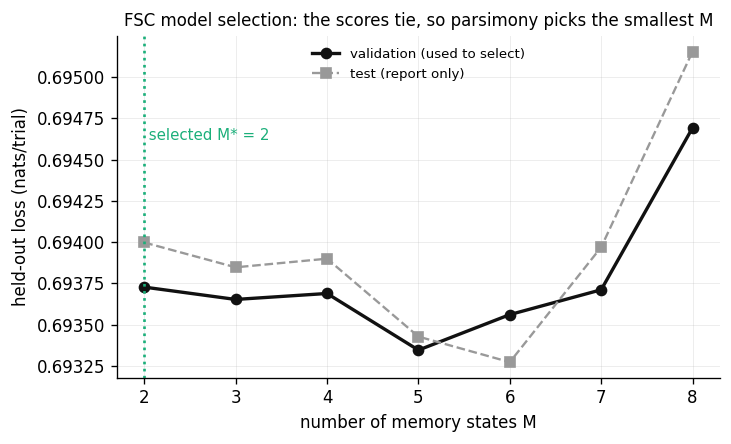

Every M from 2 to 8 lands at held-out loss ~0.6933 nats/trial. That floor
is the first trial of each session, which no model can predict; every M>=2 nails the rest.
When models tie on held-out data the smallest wins, so M* = 2: the number of memory states the
behavior actually needs. A larger fitted FSC only ever occupies 2 of its states anyway.


In [5]:
# --- 2.1 model selection: how many memory states does the behavior need? ---------------------
# The FSC was fit for each M (MAPSO, best of several restarts) and scored on held-out data; those
# scores are cached under fitted_models/<dataset>/fsc/sweep/. Here we read them back and pick M.
import json as _json, re as _re
_sweep = {}
for _p in sorted(glob.glob(os.path.join(REPO, f"fitted_models/{DATASET}/fsc/sweep/fsc_sweep_M*.losses.json"))):
    _M = int(_re.search(r"_M(\d+)\.losses", _p).group(1))
    with open(_p) as _f: _sweep[_M] = _json.load(_f)
Ms = sorted(_sweep); val = [_sweep[m]["val"] for m in Ms]; test = [_sweep[m]["test"] for m in Ms]

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(Ms, val, "o-", color=C_FSC, lw=2.0, label="validation (used to select)")
ax.plot(Ms, test, "s--", color="0.6", lw=1.4, label="test (report only)")
ax.axvline(M, color=C_SOLVED, ls=":", lw=1.6)
ax.text(M, max(val), f" selected M* = {M}", color=C_SOLVED, fontsize=9, va="top")
ax.set_xlabel("number of memory states M"); ax.set_ylabel("held-out loss (nats/trial)")
ax.set_title("FSC model selection: the scores tie, so parsimony picks the smallest M", fontsize=10)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print(f"Every M from {Ms[0]} to {Ms[-1]} lands at held-out loss ~{min(val):.4f} nats/trial. That floor")
print("is the first trial of each session, which no model can predict; every M>=2 nails the rest.")
print(f"When models tie on held-out data the smallest wins, so M* = {M}: the number of memory states the")
print(f"behavior actually needs. A larger fitted FSC only ever occupies {M} of its states anyway.")

In [6]:
# --- 2.2 the selected controller, read off as a machine --------------------------------------
print(f"M = {M} memory states, A = {A} actions, Y = {Y} observations\n")
print("pi(a | m)   which action each memory state takes")
for m in range(M):
    print("   m={}: ".format(m) + "   ".join(f"P({ACT_NAME[aa]}) = {pi[m, aa]:.4f}" for aa in range(A)))
print(f"\nrho(m)      start state: {np.round(rho, 4).tolist()}  (starts in m={int(rho.argmax())})\n")
print("g(m' | y, a, m)   where the memory moves next (unreachable rows carry no meaning)")
for m in range(M):
    for aa in range(A):
        reachable = pi[m, aa] > 1e-6
        for yy in range(Y):
            tag = f"-> m={int(g[yy, aa, m].argmax())}" if reachable else "unreachable"
            print(f"   from m={m} taking {ACT_NAME[aa]:<6} then {OBS_NAME[yy]:<5}:  {tag}")

det = np.abs(np.stack([g[yy, aa, m] for m in range(M) for aa in range(A)
                       if pi[m, aa] > 1e-6 for yy in range(Y)]).max(axis=1) - 1).max()
print(f"\nEvery reachable transition row is one-hot to within {det:.1e}, and every pi row to within "
      f"{np.abs(pi.max(axis=1) - 1).max():.1e}.")
if np.abs(pi.max(1) - 1).max() < 1e-2:
    print("So the fitted controller is deterministic: memory is a function of history, and the action a")
    print("function of memory. That is what makes the exact solve in section 5 possible.")
else:
    print("So the memory transitions are deterministic (a function of history), but at least one state plays")
    print("a STOCHASTIC action (its pi row is not one-hot). The exact solve in section 5 handles this: the")
    print("readout target at that state is its action distribution rather than a single action.")

M = 2 memory states, A = 2 actions, Y = 2 observations

pi(a | m)   which action each memory state takes
   m=0: P(a=-1) = 1.0000   P(a=+1) = 0.0000
   m=1: P(a=-1) = 0.0000   P(a=+1) = 1.0000

rho(m)      start state: [0.4881, 0.5119]  (starts in m=1)

g(m' | y, a, m)   where the memory moves next (unreachable rows carry no meaning)
   from m=0 taking a=-1   then lose :  -> m=1
   from m=0 taking a=-1   then win  :  -> m=0
   from m=0 taking a=+1   then lose :  unreachable
   from m=0 taking a=+1   then win  :  unreachable
   from m=1 taking a=-1   then lose :  unreachable
   from m=1 taking a=-1   then win  :  unreachable
   from m=1 taking a=+1   then lose :  -> m=0
   from m=1 taking a=+1   then win  :  -> m=1

Every reachable transition row is one-hot to within 1.9e-09, and every pi row to within 3.0e-10.
So the fitted controller is deterministic: memory is a function of history, and the action a
function of memory. That is what makes the exact solve in section 5 possible.


/Users/nawaf/Desktop/Vs code/FSC-Experimentations/.venv/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:457: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


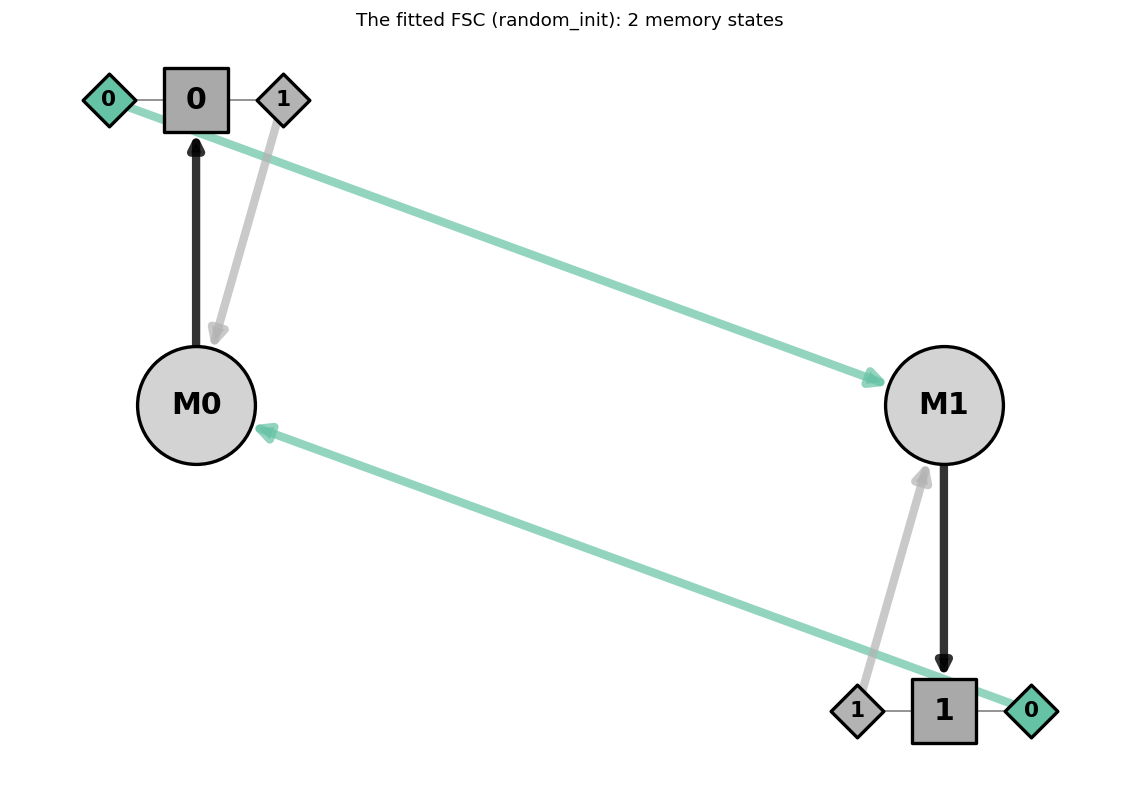

The reference the GRU is measured against: 2 memory states (circles), each taking an action
(squares) and moving to the next state after the observation (diamonds). Sections 5 and 6 ask
whether the trained network implements this same machine.


In [7]:
# --- 2.3 the controller as a diagram (drawn by the FSC-inference-MAPSO library) --------------
# This is the library's own plot_FSC, the same visualization the FSC/tinyRNN pipeline uses.
# Circles are memory states; squares are the actions each state takes; diamonds are the
# observations; edges are the memory transitions. A branch is drawn only if the policy uses it.
_use_fsc_path()
FSC["fsc"].set_mode("generation")
_axfsc = FSC["fsc"].plot_FSC(observation_node_colors=plt.cm.Set2(np.linspace(0, 1, Y)),
                            th_action_probs=1e-3, th_mem_transitions=1e-3, hide_unused_actions=True)
_axfsc.set_title(f"The fitted FSC ({DATASET}): {M} memory states", fontsize=11)
plt.show()
print(f"The reference the GRU is measured against: {M} memory states (circles), each taking an action")
print("(squares) and moving to the next state after the observation (diamonds). Sections 5 and 6 ask")
print("whether the trained network implements this same machine.")

## 3. Train the GRU

We fit GRUs the way tinyRNN does: nested cross-validation over the held-out split, one fit per
hidden size, keeping the best. We take the two smallest sizes, H=1 and H=2, because a two-state
strategy needs no more (H=1 is provably enough and H=2 matches the FSC's state count), and larger
sizes only pad the representation. The one non-default knob is the L1 penalty on the recurrent
weights, which we set to 0 here; section 5 shows exactly why that choice matters. Section 3.1 writes
the training split to disk, 3.2 runs the sweep (cached) and loads the best fit per size, and 3.3
reads back the training curves to check the fits are converged where behavior is concerned rather
than merely stopped at the epoch cap.

In [8]:
# --- 3.1 write the training split for the trainer (same split as section 0) ------------------
out_dir = os.path.join(TINYRNN_ROOT, "files", "SimpleDatasetInput")
os.makedirs(out_dir, exist_ok=True)
joblib.dump({"action":      [s["actions"] for s in TRAIN_SESS],
             "observation": [s["observations"] for s in TRAIN_SESS]},
            os.path.join(out_dir, "behavior_train.pkl"))
with open(os.path.join(out_dir, "behavior_train.dataset"), "w") as f:
    f.write(DATASET)
print(f"wrote {len(TRAIN_SESS)} training sessions to behavior_train.pkl (stamped '{DATASET}').")

wrote 800 training sessions to behavior_train.pkl (stamped 'random_init').


In [9]:
# --- 3.2 train (cached) and load the best GRU at each size -----------------------------------
# The fits live under an experiment folder named for the L1 value, so different L1 values never
# share a folder. L1 = 0 -> exp_<dataset>_l1-0. Training is skipped if the fits already exist,
# unless FORCE_RETRAIN. See scripts/train_rnn_parallel.py for the (identical) config it uses.
L1_BASELINE = 1e-5
EXP_FOLDER  = f"exp_{DATASET}" if L1_WEIGHT == L1_BASELINE else f"exp_{DATASET}_l1-{L1_WEIGHT:g}"
_live = os.path.join(TINYRNN_ROOT, "files", "saved_model", EXP_FOLDER)
_arch = os.path.join(REPO, "fitted_models", DATASET, "rnn", EXP_FOLDER)

if FORCE_RETRAIN:
    for _d in (_live, _arch):
        if os.path.isdir(_d): shutil.rmtree(_d)

if not (os.path.isdir(_live) or os.path.isdir(_arch)):
    print(f"No fits at L1 = {L1_WEIGHT:g}. Training H = {H_LIST} (this is the slow step) ...")
    subprocess.run([sys.executable, "scripts/train_rnn_parallel.py",
                    "--dataset", DATASET, "--l1", repr(L1_WEIGHT),
                    "--dims", *map(str, H_LIST)], cwd=REPO, check=True)
else:
    print(f"Using cached fits under {EXP_FOLDER}/ (set FORCE_RETRAIN = True to retrain).")

# keep a committed copy so a fresh clone does not repeat the sweep
if os.path.isdir(_live) and not os.path.isdir(_arch):
    os.makedirs(os.path.dirname(_arch), exist_ok=True); shutil.copytree(_live, _arch)

TRAINED = load_trained_rnns(EXP_FOLDER, A, Y, H_LIST)
_use_fsc_path()
print(f"loaded trained GRUs at H = {sorted(TRAINED)} (L1 = {L1_WEIGHT:g}).")

Using cached fits under exp_random_init_l1-0/ (set FORCE_RETRAIN = True to retrain).


Searching for summary files...
Found 2 summary files.
Filtering by {'agent_type': 'RNN'}


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 679.57it/s]

loaded trained GRUs at H = [1, 2] (L1 = 0).


  H   runs  % hit cap  settle epoch  best val loss  last-200 gain
  1     40       100%          1028        0.00733        4.9e-04
  2     40       100%          1529        0.01943        2.5e-03

Every run uses the full budget, and that is expected: on near-deterministic data cross-entropy
has no finite minimiser. Once the actions are right the only move left is to grow more certain,
so the loss keeps inching down and patience never fires. That is a fact about the loss scale,
not about behaviour. What matters here is that the POLICY settles before the cap (settle-epoch
column, well under the 2000 budget), so the choices the network makes have stopped changing.
Whether that settled policy is the FSC's is section 4's job, on the held-out set.


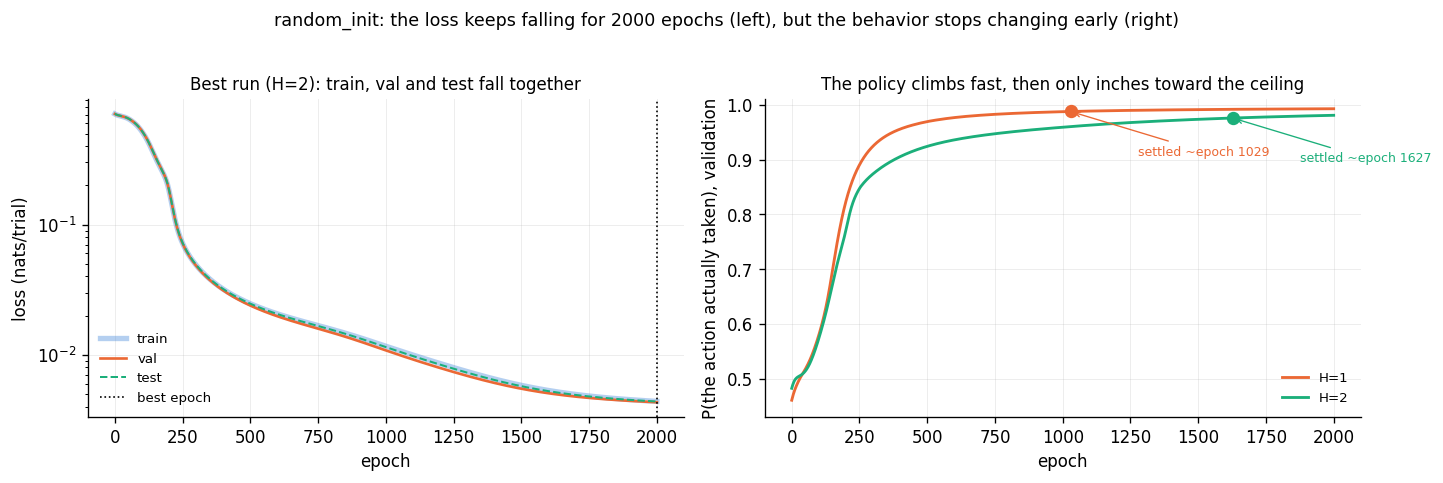

Read the two panels together. The loss (left) improves for the whole budget, but the policy
(right) -- the probability the network puts on the choice actually made -- climbs steeply and then
only inches toward its ceiling. The late training only sharpens an already-decided
policy; it does not change the behavior that sections 4 to 6 read off. That is why 'used all the
epochs' is a statement about the loss scale, not about what the network does.


In [10]:
# --- 3.3 did it converge, or just run out of epochs? -----------------------------------------
# Cross-entropy on near-deterministic data has no finite minimiser: once every action is right,
# the only thing left is to grow more certain, and the loss keeps falling like 1/epoch. So "used
# all the epochs" is a fact about the LOSS, not the model. What matters is that the POLICY settles
# early, which the curves below show. Read from the logged curves.
import re
_PATIENCE = 200
print(f"{'H':>3}  {'runs':>5}  {'% hit cap':>9}  {'settle epoch':>12}  {'best val loss':>13}  "
      f"{'last-200 gain':>13}")
_curves = {}                     # {H: [ {train, val, test} per run ]}
for H in sorted(TRAINED):
    runs = []
    for p in sorted(glob.glob(os.path.join(_live, f"*hidden_dim-{H}.*", "*", "best_pass.pkl"))):
        d = joblib.load(p)
        runs.append({k: np.asarray(d[k]["loss_log"], dtype=float) for k in ("train", "val", "test")})
    _curves[H] = runs
    val = [r["val"] for r in runs]
    caps = np.mean([len(v) - 1 >= 2000 for v in val]) * 100
    best = [v.min() for v in val]
    settle = np.median([int(np.argmax(np.exp(-v) >= np.exp(-v).max() - 0.005)) for v in val])
    tail = np.median([v[-1 - _PATIENCE] - v[-1] for v in val if len(v) > _PATIENCE])
    print(f"{H:>3}  {len(val):>5}  {caps:>8.0f}%  {settle:>12.0f}  {np.median(best):>13.5f}  "
          f"{tail:>13.1e}")
print("\nEvery run uses the full budget, and that is expected: on near-deterministic data cross-entropy")
print("has no finite minimiser. Once the actions are right the only move left is to grow more certain,")
print("so the loss keeps inching down and patience never fires. That is a fact about the loss scale,")
print("not about behaviour. What matters here is that the POLICY settles before the cap (settle-epoch")
print("column, well under the 2000 budget), so the choices the network makes have stopped changing.")
print("Whether that settled policy is the FSC's is section 4's job, on the held-out set.")

# ---- the loss curves, read straight off training ----
def _med(runs, key):
    L = min(len(r[key]) for r in runs); return np.median(np.stack([r[key][:L] for r in runs]), 0)
best_H   = min(_curves, key=lambda H: min(r["val"].min() for r in _curves[H]))
best_run = min(_curves[best_H], key=lambda r: r["val"].min())
_gate = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a"}
fig, axes = plt.subplots(1, 2, figsize=(12.2, 3.9))
ax = axes[0]
ax.plot(best_run["train"], lw=3.2, alpha=0.35, color="#2a78d6", label="train")
ax.plot(best_run["val"],   lw=1.6, color="#eb6834", label="val")
ax.plot(best_run["test"], "--", lw=1.2, color="#1baf7a", label="test")
ax.axvline(int(np.argmin(best_run["val"])), color="k", ls=":", lw=1.0, label="best epoch")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("loss (nats/trial)")
ax.set_title(f"Best run (H={best_H}): train, val and test fall together", fontsize=10)
ax.legend(fontsize=8)
ax = axes[1]
_lo = 1.0
for H in sorted(_curves):
    m = np.exp(-_med(_curves[H], "val")); _lo = min(_lo, m.min())
    ax.plot(m, color=_gate.get(H, "0.4"), lw=1.7, label=f"H={H}")
    s = int(np.argmax(m >= m.max() - 0.005))
    ax.plot([s], [m[s]], "o", color=_gate.get(H, "0.4"), ms=7)
    ax.annotate(f"settled ~epoch {s}", xy=(s, m[s]), xytext=(s + 250, m[s] - 0.08),
                fontsize=7.5, color=_gate.get(H, "0.4"),
                arrowprops=dict(arrowstyle="->", color=_gate.get(H, "0.4"), lw=0.8))
ax.set_ylim(_lo - 0.03, 1.01)                          # linear axis so the plateau is obvious
ax.set_xlabel("epoch"); ax.set_ylabel("P(the action actually taken), validation")
ax.set_title("The policy climbs fast, then only inches toward the ceiling", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
fig.suptitle(f"{DATASET}: the loss keeps falling for 2000 epochs (left), but the behavior stops changing "
             f"early (right)", y=1.02, fontsize=10.5)
plt.tight_layout(); plt.show()
print("Read the two panels together. The loss (left) improves for the whole budget, but the policy")
print("(right) -- the probability the network puts on the choice actually made -- climbs steeply and then")
print("only inches toward its ceiling. The late training only sharpens an already-decided")
print("policy; it does not change the behavior that sections 4 to 6 read off. That is why 'used all the")
print("epochs' is a statement about the loss scale, not about what the network does.")

## 4. Did the GRU learn the policy?

Three measurements on the **held-out** test sessions, each teacher-forced (every model is fed the
real history and scored on the action it predicts next). These are the standard ways to claim a
network learned a rule:

- **cross-entropy per trial** (predictive likelihood, lower is better),
- **win-stay and lose-shift rates**,
- the **action-transition matrix** P(repeat previous action | previous action, previous outcome).

If the trained GRU matches the FSC on all three, it learned the controller's policy.

In [11]:
# --- 4.1 the three on-manifold measurements, FSC vs trained GRU, on held-out sessions --------
def _ce(step_probs, sessions):
    tot, n = 0.0, 0
    for s in sessions:
        p = np.clip(step_probs(s), 1e-12, 1.0)
        tot += -np.log(p[np.arange(len(s["actions"])), s["actions"]]).sum(); n += len(s["actions"])
    return tot / n

def probs_fsc(s): return fsc_beliefs(FSC, s["actions"], s["observations"])[:-1] @ pi
def probs_rnn(P):
    return lambda s: np.array([rnn_action_probs(hv, P)
                               for hv in rnn_states(P, s["actions"], s["observations"], A, Y)[:-1]])

def transition_matrix(step_probs, sessions):
    num = np.zeros((A, Y, A)); den = np.zeros((A, Y))
    for s in sessions:
        a, o = s["actions"], s["observations"]; p = step_probs(s)
        for t in range(1, len(a)):
            num[a[t-1], o[t-1]] += p[t]; den[a[t-1], o[t-1]] += 1
    return num / np.maximum(den, 1)[:, :, None]

def transition_matrix_data(sessions):
    num = np.zeros((A, Y, A)); den = np.zeros((A, Y))
    for s in sessions:
        a, o = s["actions"], s["observations"]
        for t in range(1, len(a)):
            num[a[t-1], o[t-1], a[t]] += 1; den[a[t-1], o[t-1]] += 1
    return num / np.maximum(den, 1)[:, :, None]

def rates(T): return (float(np.mean([T[aa, WIN, aa] for aa in range(A)])),
                      float(np.mean([1 - T[aa, LOSE, aa] for aa in range(A)])))

MODELS = [("FSC", probs_fsc)] + [(f"trained H={H}", probs_rnn(TRAINED[H])) for H in H_LIST]
T_data = transition_matrix_data(TEST_SESS)

# CE plus the action-transition matrix read as numbers: P(repeat the previous action) in each
# (previous action, previous outcome) condition. That subsumes the win-stay / lose-shift rates and
# works for any task, WSLS or not; the data row is the target.
_conds = [(aa, yy) for aa in range(A) for yy in range(Y)]
print(f"Held-out test set ({len(TEST_SESS)} sessions), teacher-forced. Lower CE is better; the other")
print(f"columns are P(repeat the previous action) per (previous action, previous outcome).\n")
print(f"{'model':>13}  {'CE/trial':>9}  " + "  ".join(f"{ACT_NAME[aa]+','+OBS_NAME[yy]:>11}" for (aa, yy) in _conds))
def _prow(name, T, ce):
    cells = "  ".join(f"{T[aa, yy, aa]:>11.4f}" for (aa, yy) in _conds)
    print(f"{name:>13}  {(ce if isinstance(ce, str) else format(ce, '.5f')):>9}  {cells}")
_prow("data", T_data, "--")
for nm, sp in MODELS:
    _prow(nm, transition_matrix(sp, TEST_SESS), _ce(sp, TEST_SESS))
_fsc_ce = _ce(probs_fsc, TEST_SESS)
_match  = [H for H in H_LIST if _ce(probs_rnn(TRAINED[H]), TEST_SESS) <= _fsc_ce + 0.02]
_miss   = [H for H in H_LIST if H not in _match]
if _miss:
    print(f"\nSizes H = {_match} reproduce the FSC's held-out likelihood; H = {_miss} do NOT (their CE stays")
    print(f"well above the FSC's {_fsc_ce:.4f}). The smallest sizes fit the data but not the policy: training")
    print(f"at that size does not reach a good fit, even where section 5.2 shows an exact solution DOES exist")
    print(f"there. So 'small enough to represent' and 'reachable by training' are different, which section 5")
    print(f"is about.")
else:
    print("\nEvery trained size reproduces the FSC's held-out likelihood and its full transition matrix. On")
    print("the standard measurements the GRU learned the policy. Whether it learned the RULE, as opposed to")
    print("fitting the data it saw, is a different question, taken up in section 5.")

Held-out test set (200 sessions), teacher-forced. Lower CE is better; the other
columns are P(repeat the previous action) per (previous action, previous outcome).

        model   CE/trial    a=-1,lose     a=-1,win    a=+1,lose     a=+1,win
         data         --       0.0000       1.0000       0.0000       1.0000
          FSC    0.00346       0.0000       1.0000       0.0000       1.0000


  trained H=1    0.00797       0.0008       0.9978       0.0033       0.9917


  trained H=2    0.00439       0.0010       0.9997       0.0019       0.9994



Every trained size reproduces the FSC's held-out likelihood and its full transition matrix. On
the standard measurements the GRU learned the policy. Whether it learned the RULE, as opposed to
fitting the data it saw, is a different question, taken up in section 5.


## 5. The analytical GRU that *is* the controller

A GRU that learned the rule perfectly would place its hidden state exactly on the controller's
memory states and never move off them. We can construct that GRU directly, without training: solve
for weights and an embedding E (which hidden vector stands for which memory state) so that one GRU
step from a state lands exactly where the FSC's table says, and the readout plays exactly what the
state says. This gives an exact target. We then compare the trained GRU, the solved GRU, and the FSC.

In [12]:
# --- 5.1 the requirement list and the solver -------------------------------------------------
def machine_constraints(pi, g, rho, p_min=1e-6):
    """Every (state, action, outcome) the machine can be in (skip pi(a|m)=0 rows), plus the start."""
    M, A = pi.shape; Y = g.shape[0]
    trans = [(m, a, y, g[y, a, m]) for m in range(M) for a in range(A)
             if pi[m, a] > p_min for y in range(Y)]
    return trans, int(np.argmax(rho))

def _shapes(H, A, Y, M):
    return [("W_ih", (3*H, A+Y)), ("b_ih", (3*H,)), ("W_hh", (3*H, H)), ("b_hh", (3*H,)),
            ("lin_W", (A, H)), ("lin_b", (A,)), ("E", (H, M))]
def _unpack(theta, H, A, Y, M):
    out, i = {}, 0
    for k, sh in _shapes(H, A, Y, M):
        n = int(np.prod(sh)); out[k] = theta[i:i+n].reshape(sh); i += n
    return out

def solve_gru_for_fsc(pi, g, rho, H, conf=1e-3, pin_h0=True, lam=3e-2, restarts=5,
                      seed=0, exact_tol=1e-8):
    """Solve for GRU weights and embedding E so the GRU IS the machine (pi, g, rho). Returns
    (P, E, residual). conf pulls the one-hot policy off the softmax vertex (the certainty cap);
    pin_h0 fixes the start state at h=0 where tinyRNN starts; among exact solutions the smallest
    weights are kept. Nothing about WSLS is hard-coded; the machine is an argument."""
    M, A = pi.shape; Y = g.shape[0]
    trans, m0 = machine_constraints(pi, g, rho); K = len(trans)
    npar = sum(int(np.prod(sh)) for _, sh in _shapes(H, A, Y, M))
    m_idx = torch.tensor([t[0] for t in trans])
    Xb = torch.zeros(K, A + Y)
    for i, (m, a, y, _) in enumerate(trans): Xb[i, a] = 1.0; Xb[i, A + y] = 1.0
    Gn      = torch.tensor(np.stack([t[3] for t in trans]))
    log_tgt = torch.tensor(np.log((1.0 - conf) * pi + conf / A))

    def residual_t(theta, lam_t):
        P = _unpack(theta, H, A, Y, M); E = P["E"]
        Hb = E[:, m_idx].T
        gi = Xb @ P["W_ih"].T + P["b_ih"]; gh = Hb @ P["W_hh"].T + P["b_hh"]
        r = torch.sigmoid(gi[:, :H] + gh[:, :H]); z = torch.sigmoid(gi[:, H:2*H] + gh[:, H:2*H])
        n = torch.tanh(gi[:, 2*H:] + r * gh[:, 2*H:])
        r_trans = ((1 - z) * n + z * Hb) - Gn @ E.T
        r_read  = torch.log_softmax(E.T @ P["lin_W"].T + P["lin_b"], 1) - log_tgt
        parts = [r_trans.reshape(-1), r_read.reshape(-1)]
        if pin_h0: parts.append(E[:, m0])
        parts.append(lam_t * theta)
        return torch.cat(parts)

    jac_fn = jacrev(residual_t)
    def f(th, lv): return residual_t(torch.tensor(th), torch.tensor(lv)).numpy()
    def J(th, lv): return jac_fn(torch.tensor(th), torch.tensor(lv)).numpy()
    kw = dict(jac=J, method="lm", xtol=1e-15, ftol=1e-15, gtol=1e-15, max_nfev=5000)
    best, rng = None, np.random.default_rng(seed)
    for _ in range(restarts):
        th = 0.5 * rng.standard_normal(npar)
        th = least_squares(f, th, args=(lam,),   **kw).x
        th = least_squares(f, th, args=(1e-12,), **kw).x
        res = float(np.abs(f(th, 0.0)).max()); key = (res > exact_tol, float(np.linalg.norm(th)))
        if best is None or key < best[0]: best = (key, res, th)
    _, res, th = best
    P = {k: v.numpy().copy() for k, v in _unpack(torch.tensor(th), H, A, Y, M).items()}
    E = P.pop("E"); P["H"] = H
    return P, E, res

TRANS, M0 = machine_constraints(pi, g, rho)
print(f"{len(TRANS)} transition requirements + {M} readout + 1 start requirement.")
print("Each says: one GRU step from the vector for m, under (a, y), must land ON the vector for the")
print("next state, and the readout there must play pi(. | m). Solving for exactness, not resemblance.")

4 transition requirements + 2 readout + 1 start requirement.
Each says: one GRU step from the vector for m, under (a, y), must land ON the vector for the
next state, and the readout there must play pi(. | m). Solving for exactness, not resemblance.


In [13]:
# --- 5.2 solve at each size and verify by replay through the numpy GRU ------------------------
SOLVED, EMB, RESID = {}, {}, {}
for H in H_LIST:
    t0 = time.time()
    SOLVED[H], EMB[H], RESID[H] = solve_gru_for_fsc(pi, g, rho, H)
    print(f"H = {H}: solved, max requirement violation {RESID[H]:.2e}  ({time.time()-t0:.1f}s)")

print(f"\n{'H':>3}  {'max violation':>14}  {'max |weight|':>13}   embedded states (columns of E)")
for H in H_LIST:
    P, E = SOLVED[H], EMB[H]
    mw = max(np.abs(v).max() for k, v in P.items() if k != "H")
    cols = "   ".join(f"e_{m}={np.round(E[:, m], 4).tolist()}" for m in range(M))
    print(f"{H:>3}  {RESID[H]:>14.2e}  {mw:>13.3f}   {cols}")

# independent replay: run each requirement through gru_step (untouched by the solver)
print(f"\nReplayed through the plain numpy gru_step (an independent check):")
print(f"{'H':>3}  {'transitions':>12}  {'readout':>10}  {'start state':>12}")
for H in H_LIST:
    P, E = SOLVED[H], EMB[H]
    tt = max(np.abs(gru_step(E[:, m], encode_input(a, y, A, Y), P)[0] - E @ gn).max()
             for (m, a, y, gn) in TRANS)
    rr = max(np.abs(rnn_action_probs(E[:, m], P) - ((1 - 1e-3) * pi[m] + 1e-3 / A)).max() for m in range(M))
    print(f"{H:>3}  {tt:>12.2e}  {rr:>10.2e}  {np.abs(E[:, M0]).max():>12.2e}")

# The requirements only pin the reachable POINTS. The real test is whether the solved GRU reproduces
# the FSC when RUN over whole sessions: its teacher-forced CE should equal the FSC's. Where it does
# not, the solve is exact at its own points but not a valid controller over data (unconstrained
# transitions can diverge between the points), and it should not be trusted as "the exact GRU".
_fce = _ce(probs_fsc, TEST_SESS)
print(f"\nRun over whole held-out sessions (teacher-forced CE; a valid controller matches the FSC's {_fce:.4f}):")
_valid = []
for H in H_LIST:
    _sce = _ce(probs_rnn(SOLVED[H]), TEST_SESS); _ok = abs(_sce - _fce) < 0.05
    _valid.append(_ok)
    print(f"   solved H={H}: CE = {_sce:.4f}   ({'matches -> valid over data' if _ok else 'does NOT match -> exact at its points but diverges over data'})")
if not all(_valid):
    print("   (a non-matching size satisfies the point requirements but is not a usable controller; its")
    print("    weights route real trajectories through unconstrained regions that blow up.)")
_exact = [H for H in H_LIST if RESID[H] < 1e-6]; _fail = [H for H in H_LIST if RESID[H] >= 1e-6]
if _fail:
    print(f"\nExact solutions exist at H = {_exact} (violation < 1e-6) but NOT at H = {_fail}: those sizes")
    print(f"cannot BE this machine, the requirements have no exact solution there. For an M-state controller")
    print(f"a GRU needs enough hidden directions, so H below that is a hard limit, not an optimisation")
    print(f"failure. Section 4's policy table shows whether training at those sizes still fit the DATA.")
else:
    print("\nUnder 1e-6 at every size shown: these are solutions, not fits.")
print("The 'max |weight|' column matters across datasets: saturating a gate to hold or switch a state")
print("exactly needs a large weight, and a harder machine (more states, larger H) needs larger ones. If")
print("the exact solution lives at large weights, that is part of why small-initialised training, which")
print("starts near zero, never drifts toward it (section 5.5).")

H = 1: solved, max requirement violation 6.19e-10  (12.0s)


H = 2: solved, max requirement violation 5.93e-10  (13.6s)

  H   max violation   max |weight|   embedded states (columns of E)
  1        6.19e-10         11.843   e_0=[0.9427]   e_1=[0.0]
  2        5.93e-10         11.839   e_0=[0.0, -0.9477]   e_1=[0.0, -0.0]

Replayed through the plain numpy gru_step (an independent check):
  H   transitions     readout   start state
  1      6.19e-10    4.77e-15      4.09e-19
  2      5.93e-10    3.90e-15      3.83e-19

Run over whole held-out sessions (teacher-forced CE; a valid controller matches the FSC's 0.0035):
   solved H=1: CE = 0.0417   (matches -> valid over data)
   solved H=2: CE = 0.0417   (matches -> valid over data)

Under 1e-6 at every size shown: these are solutions, not fits.
The 'max |weight|' column matters across datasets: saturating a gate to hold or switch a state
exactly needs a large weight, and a harder machine (more states, larger H) needs larger ones. If
the exact solution lives at large weights, that is part of why sm

In [14]:
# --- 5.3 do trained and solved sit on the FSC's memory state? --------------------------------
def compare_solved(P, E, sessions):
    """The solved net has an embedding, so compare its hidden state directly to E @ b_t."""
    d, agree, n = [], 0, 0
    for s in sessions:
        b = fsc_beliefs(FSC, s["actions"], s["observations"])
        h = rnn_states(P, s["actions"], s["observations"], A, Y)
        d.append(np.linalg.norm(h - b @ E.T, axis=1))
        p_rnn = np.array([rnn_action_probs(hv, P) for hv in h])
        agree += int((p_rnn.argmax(1) == (b @ pi).argmax(1)).sum()); n += len(h)
    d = np.concatenate(d); return np.median(d), d.mean(), d.max(), agree / n

def compare_trained(P, sessions):
    """The trained net has no embedding, so give it the BEST affine map from h to the FSC belief,
    fitted by least squares on this data. Whatever it leaves over is error no linear readout could
    remove. This handicaps the comparison in the trained net's favour."""
    X, B = [], []
    for s in sessions:
        X.append(rnn_states(P, s["actions"], s["observations"], A, Y))
        B.append(fsc_beliefs(FSC, s["actions"], s["observations"]))
    X = np.concatenate(X); B = np.concatenate(B); Xa = np.hstack([X, np.ones((len(X), 1))])
    with quiet_blas():
        W, *_ = np.linalg.lstsq(Xa, B, rcond=None)
        rn = np.linalg.norm(B - Xa @ W, axis=1)
        p_rnn = np.array([rnn_action_probs(hv, P) for hv in X])
        acc = (p_rnn.argmax(1) == (B @ pi).argmax(1)).mean()
    return np.median(rn), rn.mean(), rn.max(), acc

print("Is the FSC's memory state linearly readable from the GRU's hidden state? For the SOLVED net it is")
print("exact by construction (its hidden state IS the embedding E @ belief). For the TRAINED net we fit the")
print("best affine map from hidden state to the FSC belief and report the residual it cannot explain: a")
print("small gap means the memory is there and linearly decodable, a large one (as when H is too small for")
print(f"the machine) means it is not. Over the {len(TEST_SESS)} held-out sessions.\n")
print(f"{'model':>13}  {'median gap':>11}  {'mean gap':>10}  {'worst gap':>10}  "
      f"{'measured against':>20}  {'same action':>12}")
for H in H_LIST:
    md, mn, mx, acc = compare_solved(SOLVED[H], EMB[H], TEST_SESS)
    print(f"{'solved H='+str(H):>13}  {md:>11.2e}  {mn:>10.2e}  {mx:>10.2e}  "
          f"{'its own embedding':>20}  {acc:>12.2%}")
for H in H_LIST:
    md, mn, mx, acc = compare_trained(TRAINED[H], TEST_SESS)
    print(f"{'trained H='+str(H):>13}  {md:>11.2e}  {mn:>10.2e}  {mx:>10.2e}  "
          f"{'best-fit affine map':>20}  {acc:>12.2%}")

# The solved net's mean/worst gap: on datasets with an unobserved start it is the first trial only.
if rho.max() < 0.99:
    m0_action = int(pi[int(rho.argmax())].argmax()); d_body, off_start = [], 0
    for s in TEST_SESS:
        b = fsc_beliefs(FSC, s["actions"], s["observations"])
        h = rnn_states(SOLVED[H_STAR], s["actions"], s["observations"], A, Y)
        d_body.append(np.linalg.norm(h - b @ EMB[H_STAR].T, axis=1)[1:])
        off_start += int(int(s["actions"][0]) != m0_action)
    d_body = np.concatenate(d_body)
    print(f"\nThe solved GRU's hidden state IS the embedding of the memory state to a MEDIAN of {np.median(d_body):.1e}")
    print(f"on the trials the data constrains. Its larger mean and worst are the session START: {DATASET} leaves")
    print(f"the initial state unobserved, and {off_start}/{len(TEST_SESS)} sessions open with an action the start")
    print(f"state never plays; only {(d_body > 0.01).mean()*100:.1f}% of later trials exceed a 0.01 gap. That")
    print(f"is a property of the data, not the solve.")
else:
    _sd = compare_solved(SOLVED[H_STAR], EMB[H_STAR], TEST_SESS)
    print(f"\n{DATASET} has a fixed (one-hot) start, so there is no unobserved first trial. The solved GRU at")
    print(f"H={H_STAR} sits on the FSC memory state to a median of {_sd[0]:.1e}. Where the mean or worst gap is")
    print(f"larger it is memory states whose own action is stochastic: the belief filter cannot fully collapse")
    print(f"there, so the 'embedding of the belief' is itself a spread rather than a point.")
print("The trained networks carry the same memory only approximately: the affine-map gap is how much of the")
print("FSC state a linear readout of the GRU cannot recover. Section 6 shows this geometry directly.")

Is the FSC's memory state linearly readable from the GRU's hidden state? For the SOLVED net it is
exact by construction (its hidden state IS the embedding E @ belief). For the TRAINED net we fit the
best affine map from hidden state to the FSC belief and report the residual it cannot explain: a
small gap means the memory is there and linearly decodable, a large one (as when H is too small for
the machine) means it is not. Over the 200 held-out sessions.

        model   median gap    mean gap   worst gap      measured against   same action
   solved H=1     2.79e-09    1.10e-02    9.43e-01     its own embedding        99.69%


   solved H=2     2.77e-09    1.08e-02    9.48e-01     its own embedding        99.69%


  trained H=1     3.37e-02    3.78e-02    7.92e-01   best-fit affine map        99.97%


  trained H=2     1.97e-02    3.52e-02    7.21e-01   best-fit affine map        99.50%



The solved GRU's hidden state IS the embedding of the memory state to a MEDIAN of 2.8e-09
on the trials the data constrains. Its larger mean and worst are the session START: random_init leaves
the initial state unobserved, and 91/200 sessions open with an action the start
state never plays; only 3.0% of later trials exceed a 0.01 gap. That
is a property of the data, not the solve.
The trained networks carry the same memory only approximately: the affine-map gap is how much of the
FSC state a linear readout of the GRU cannot recover. Section 6 shows this geometry directly.


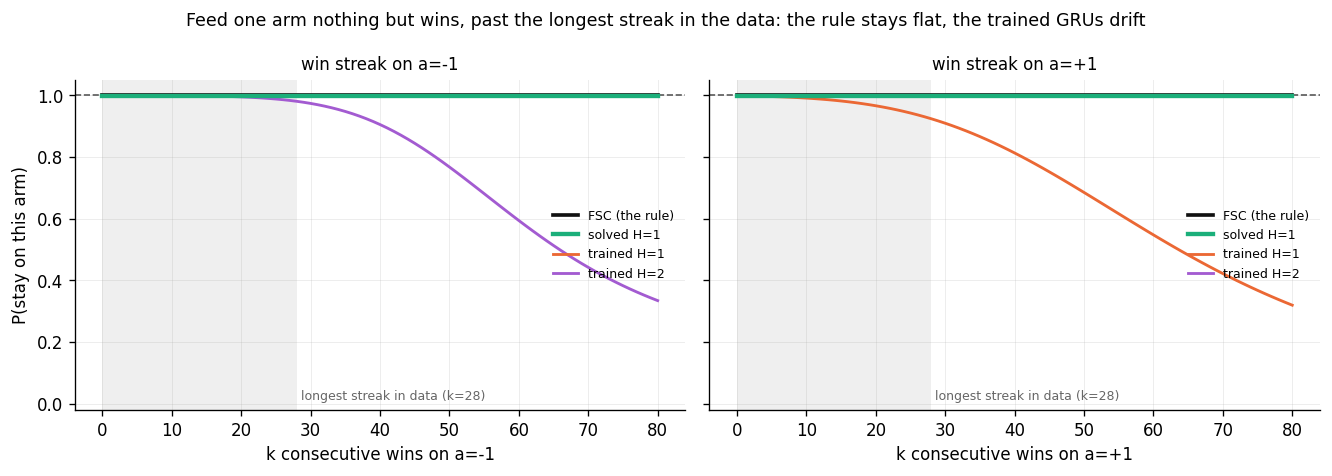

Worst move in P(stay) across the streak (0 = holds win-stay), per arm and size:

     arm   trained H=1   trained H=2     solved
    a=-1      3.23e-04      6.66e-01   3.99e-10
    a=+1      6.80e-01      3.67e-05   2.22e-15

Inside the shaded band (streaks the data contains) every model holds win-stay. Past it the solved
GRU and the FSC stay flat because they IMPLEMENT the rule; a trained GRU holds only if its own
dynamics keep it in the win-state forever, which the fits do not guarantee. That gap is 5.5's subject.


In [15]:
# --- 5.4 the off-manifold probe: after k straight wins on an arm, does P(stay) hold? ---------
# Start every model in the state where it just won on the arm (its median hidden state right after
# a win on real data), then feed (that arm, won) k more times, past the longest win streak the data
# ever contained. Win-stay says the only correct curve is FLAT. This works for any number of memory
# states: a 3-state task's extra state is a losing / reset state, so a win streak never sits in it.
def win_state(a0): return int(np.argmax(pi[:, a0]))
def win_h(P, a0, n=100):
    hs = []
    for s in SESS[:n]:
        h = np.zeros(P["H"])
        for t in range(len(s["actions"])):
            h, _ = gru_step(h, encode_input(s["actions"][t], s["observations"][t], A, Y), P)
            if s["actions"][t] == a0 and s["observations"][t] == WIN: hs.append(h.copy())
    return np.median(np.stack(hs), 0) if hs else np.zeros(P["H"])
def rnn_probe(P, a0, kmax=KMAX):
    h = np.asarray(win_h(P, a0), float); x = encode_input(a0, WIN, A, Y); out = [rnn_action_probs(h, P)[a0]]
    for _ in range(kmax): h, _ = gru_step(h, x, P); out.append(rnn_action_probs(h, P)[a0])
    return np.array(out)
def fsc_probe(a0, kmax=KMAX):
    b = np.zeros(M); b[win_state(a0)] = 1.0; out = [float((b @ pi)[a0])]
    for _ in range(kmax):
        bn = b @ FSC["TMat"][WIN, :, :, a0]; s = bn.sum(); b = bn / s if s > 0 else b
        out.append(float((b @ pi)[a0]))
    return np.array(out)
def probe_drift(P, kmax=KMAX):
    return max(float(np.ptp(rnn_probe(P, a0, kmax))) for a0 in range(A))

_HC = {1: C_TRAINED, 2: "#a35bd1", 3: "#2a78d6", 4: "#e34a6f"}
kk = np.arange(KMAX + 1)
_pc = {a0: {"fsc": fsc_probe(a0), "solved": rnn_probe(SOLVED[H_STAR], a0),
            **{H: rnn_probe(TRAINED[H], a0) for H in H_LIST}} for a0 in range(A)}   # compute once
fig, axes = plt.subplots(1, A, figsize=(5.6 * A, 4.0), sharey=True, squeeze=False); axes = axes[0]
for a0 in range(A):
    ax = axes[a0]; ax.axvspan(0, MAX_STREAK, color=SHADE, alpha=0.13, lw=0)
    ax.text(MAX_STREAK, 0.02, f" longest streak in data (k={MAX_STREAK})", fontsize=7.5, color="0.4",
            ha="left", va="bottom", transform=ax.get_xaxis_transform())
    ax.axhline(1.0, color=C_RULE, ls="--", lw=1.0)
    ax.plot(kk, _pc[a0]["fsc"], color=C_FSC, lw=2.2, label="FSC (the rule)", zorder=5)
    ax.plot(kk, _pc[a0]["solved"], color=C_SOLVED, lw=2.6, label=f"solved H={H_STAR}", zorder=6)
    for H in H_LIST:
        ax.plot(kk, _pc[a0][H], color=_HC.get(H, "0.4"), lw=1.7, label=f"trained H={H}")
    ax.set_xlabel(f"k consecutive wins on {ACT_NAME[a0]}")
    ax.set_title(f"win streak on {ACT_NAME[a0]}", fontsize=10); ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=7.5, loc="center right")
axes[0].set_ylabel("P(stay on this arm)")
fig.suptitle("Feed one arm nothing but wins, past the longest streak in the data: the rule stays flat, "
             "the trained GRUs drift", fontsize=10.5)
plt.tight_layout(); plt.show()

print("Worst move in P(stay) across the streak (0 = holds win-stay), per arm and size:\n")
print(f"{'arm':>8}  " + "  ".join(f"{'trained H='+str(H):>12}" for H in H_LIST) + f"  {'solved':>9}")
for a0 in range(A):
    row = "  ".join(f"{float(np.ptp(_pc[a0][H])):>12.2e}" for H in H_LIST)
    print(f"{ACT_NAME[a0]:>8}  {row}  {float(np.ptp(_pc[a0]['solved'])):>9.2e}")
print("\nInside the shaded band (streaks the data contains) every model holds win-stay. Past it the solved")
print("GRU and the FSC stay flat because they IMPLEMENT the rule; a trained GRU holds only if its own")
print("dynamics keep it in the win-state forever, which the fits do not guarantee. That gap is 5.5's subject.")

### 5.5 So why doesn't training reach this exact GRU?

Section 4 showed the trained GRU matches the FSC on the data but drifts off-manifold, and the exact
GRU above does not. If removing the L1 penalty was supposed to fix that, it did not. To find out why,
we train small GRUs here ourselves, with the same optimiser as the committed fits, and watch the
off-manifold drift **as training proceeds** rather than only at the end. Everything below runs at the
lead size H_STAR (the smallest hidden size that can be the exact controller), and the off-manifold
metric is the task-general probe drift from section 5.4.

In [16]:
# --- 5.5 the training harness (same optimiser as the fitted GRUs), at H=1 --------------------
import torch.nn as nn
HINV = H_STAR                                    # the investigation runs at the minimal size

def build_tensors(sessions):
    T = len(sessions[0]["actions"]); B = len(sessions)
    X = np.zeros((T, B, A + Y)); Tg = np.zeros((T, B), dtype=np.int64)
    for b, s in enumerate(sessions):
        X[np.arange(T), b, s["actions"]] = 1.0
        X[np.arange(T), b, A + s["observations"]] = 1.0
        Tg[:, b] = s["actions"]
    return torch.tensor(X), torch.tensor(Tg)
XT, TT = build_tensors(TRAIN_SESS)

class TinyGRU(nn.Module):
    """The exact graph tinyRNN builds for (GRU, readout_FC, trainable_h0=False, output_h0=True)."""
    def __init__(self, Hd):
        super().__init__(); self.rnn = nn.GRU(A + Y, Hd); self.lin = nn.Linear(Hd, A); self.Hd = Hd
    def forward(self, X):
        h0 = torch.zeros(1, X.shape[1], self.Hd, dtype=X.dtype)
        out, _ = self.rnn(X, h0); out = torch.cat((h0, out), 0)
        return self.lin(out)[:-1]

def to_model(P):
    m = TinyGRU(P["H"]).double()
    with torch.no_grad():
        m.rnn.weight_ih_l0.copy_(torch.tensor(P["W_ih"])); m.rnn.weight_hh_l0.copy_(torch.tensor(P["W_hh"]))
        m.rnn.bias_ih_l0.copy_(torch.tensor(P["b_ih"]));   m.rnn.bias_hh_l0.copy_(torch.tensor(P["b_hh"]))
        m.lin.weight.copy_(torch.tensor(P["lin_W"]));      m.lin.bias.copy_(torch.tensor(P["lin_b"]))
    return m
def to_params(m):
    gp = lambda x: x.detach().numpy().copy()
    return {"W_ih": gp(m.rnn.weight_ih_l0), "W_hh": gp(m.rnn.weight_hh_l0), "b_ih": gp(m.rnn.bias_ih_l0),
            "b_hh": gp(m.rnn.bias_hh_l0), "lin_W": gp(m.lin.weight), "lin_b": gp(m.lin.bias), "H": m.Hd}

_celoss = nn.CrossEntropyLoss()
def behav_loss(m): return _celoss(m(XT).reshape(-1, A), TT.reshape(-1))

# off-manifold drift uses the task-general probe_drift defined in 5.4 (max output move over the
# recurring inputs). DRIFT_TOL below is the "flat enough to call it holding the rule" threshold.
def on_manifold_acc(P):
    with torch.no_grad(): pred = to_model(P)(XT).argmax(-1)
    return float((pred == TT).double().mean())
def min_z_on_win(P):
    E = EMB[HINV]; out = []
    for m in range(M):
        _, gt = gru_step(E[:, m], encode_input(int(np.argmax(pi[m])), WIN, A, Y), P)
        out.append(float(gt["update"].min()))
    return float(min(out))
def rec_l1(P): return float(np.abs(P["W_ih"]).sum() + np.abs(P["W_hh"]).sum())

# The best achievable on-manifold accuracy is the FSC's own: on random_init the first trial of each
# session is unpredictable (~50/50 start), so no model reaches 100%. Measure "learned the policy"
# against that ceiling, not against 1.0, or every random_init run wrongly reads as a failure.
FSC_ACC = float(np.concatenate([
    (fsc_beliefs(FSC, s["actions"], s["observations"])[:-1] @ pi).argmax(1) == s["actions"]
    for s in TRAIN_SESS]).mean())
DRIFT_TOL, ACC_MARGIN = 1e-2, 0.02
def learned_policy(a): return a >= FSC_ACC - ACC_MARGIN   # excludes collapsed runs, not trial-0 noise
def verdict(P):
    a, d = on_manifold_acc(P), probe_drift(P)
    return a, d, (learned_policy(a) and d < DRIFT_TOL)

def train_tracked(P, epochs=2000, seed=0, every=100, l1w=0.0):
    """Train from weights P; snapshot loss, drift, accuracy and the hold gate every `every` epochs."""
    torch.manual_seed(seed); m = to_model(P)
    opt = torch.optim.AdamW(m.parameters(), lr=0.005, weight_decay=0.0)
    curve, log = np.empty(epochs), []
    def snap(e):
        Q = to_params(m)
        log.append(dict(epoch=e, loss=float(behav_loss(m)), drift=probe_drift(Q),
                        acc=on_manifold_acc(Q), z=min_z_on_win(Q), rl1=rec_l1(Q)))
    for e in range(epochs):
        if e % every == 0: snap(e)
        opt.zero_grad(); bl = behav_loss(m)
        (bl + l1w * (m.rnn.weight_ih_l0.abs().sum() + m.rnn.weight_hh_l0.abs().sum())).backward()
        opt.step(); curve[e] = bl.item()
    snap(epochs); return to_params(m), curve, log

KEYS = ("W_ih", "W_hh", "b_ih", "b_hh", "lin_W", "lin_b")
flat = lambda P: np.concatenate([np.asarray(P[k]).ravel() for k in KEYS])
TH0  = flat(SOLVED[HINV])
def perturb(P, eps, seed):
    rng = np.random.default_rng(seed)
    Q = {k: np.asarray(P[k]) + eps * rng.standard_normal(np.asarray(P[k]).shape) for k in KEYS}
    Q["H"] = P["H"]; return Q
def random_start(seed):
    torch.manual_seed(seed); return to_params(TinyGRU(HINV).double())

with torch.no_grad(): _sc = to_model(SOLVED[HINV])(XT[:, :1])[:, 0].numpy()
_h, _mx = np.zeros(HINV), 0.0
for t in range(len(TRAIN_SESS[0]["actions"])):
    _mx = max(_mx, np.abs(_softmax(_sc[t]) - rnn_action_probs(_h, SOLVED[HINV])).max())
    _h, _ = gru_step(_h, encode_input(TRAIN_SESS[0]["actions"][t], TRAIN_SESS[0]["observations"][t], A, Y), SOLVED[HINV])
print(f"harness ready (H={HINV}). torch graph vs numpy GRU, worst |dP| over a session: {_mx:.1e}")
print(f"a run 'holds the rule' if accuracy = 100% and off-manifold drift < {DRIFT_TOL:g}.")

harness ready (H=1). torch graph vs numpy GRU, worst |dP| over a session: 2.2e-16
a run 'holds the rule' if accuracy = 100% and off-manifold drift < 0.01.


### 5.6 Three starting points, one optimiser

Train the same GRU three ways and watch the off-manifold drift over epochs:

- **cold start, L1=0** is how the committed fits were made: random initial weights, no penalty.
- **from the exact GRU, L1=0** starts training *at* the solved weights, to ask whether the loss even
  wants to stay there.
- **from the exact GRU, L1=1e-5** turns the old penalty back on from the same start, to isolate what L1
  does.

The headline is the left panel. Win-stay says the drift must be zero for any streak length, so a flat
line at the bottom is the only correct answer.

computing the three investigation runs at H=1 (cached after this) ...


/var/folders/sx/0rzxsvdd2_5cnl5325lfvn2r0000gn/T/ipykernel_62438/2003182771.py:71: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  log.append(dict(epoch=e, loss=float(behav_loss(m)), drift=probe_drift(Q),


  done in 200s
of 3 cold seeds, 2 learned the policy and 1 collapsed to a degenerate always-repeat policy; the curve below shows the best-learning cold seed (2).

      start / penalty  final loss  final acc  final drift  holds rule?


 cold start (learned)     0.00817     0.9973     5.91e-01           NO


     from exact, L1=0     0.00527     0.9975     9.45e-11          yes


  from exact, L1=1e-5     0.00824     0.9944     4.09e-06          yes


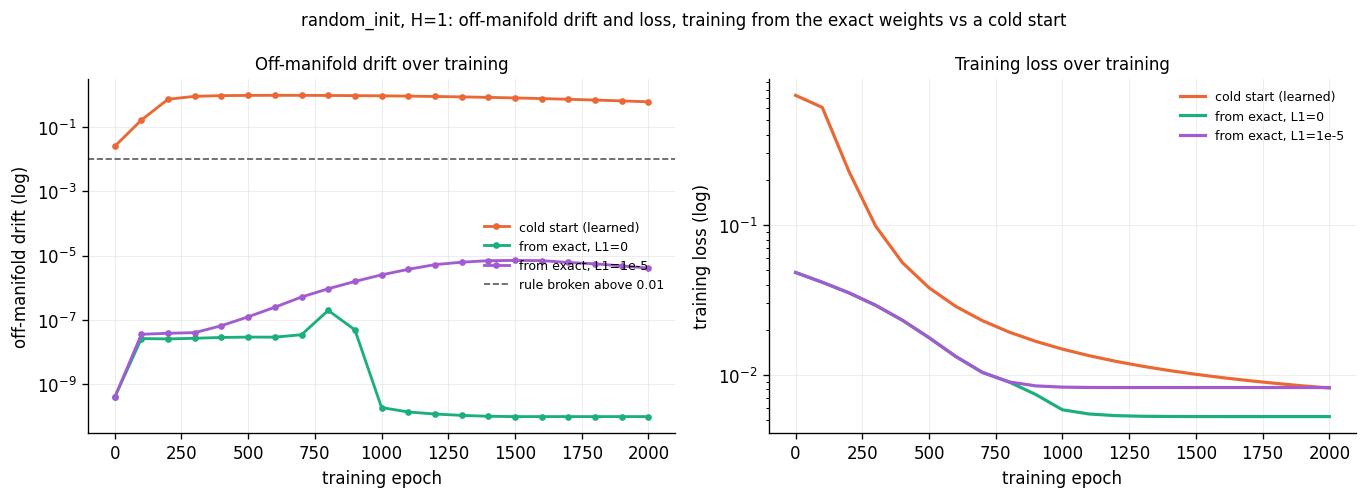


Read the final off-manifold drift of each run:
  cold start          -> 5.9e-01  (learned the policy, never brings the drift down)
  from exact, L1=0     -> 9.5e-11  (holds the exact solution)
  from exact, L1=1e-5  -> 4.1e-06  (holds)
Cross-entropy is happy to SIT at the exact weights, so L1=0 holds them; the L1 penalty pulls the
network off, because saturating the gates needs large weights and L1 charges for exactly that.
Either way, the exact solution is never reached from a cold start: the loss cannot see the off-manifold
behaviour that distinguishes it, so nothing selects it. 'Representable' (5.2) and 'reachable by
training' come apart, most sharply at the smallest size that can still represent the task.


In [17]:
# --- 5.6 train from three starting points, tracking drift over epochs (cached) --------------
EPOCHS_INV = 2000
COLD_SEEDS = [0, 2, 4]
INV_DIR = os.path.join(REPO, "fitted_models", DATASET, "investigation")
os.makedirs(INV_DIR, exist_ok=True)
FORCE_INVESTIGATION = False                     # True re-runs 5.6 and 5.7 from scratch
_sig56  = dict(dataset=DATASET, H=HINV, epochs=EPOCHS_INV, cold=list(COLD_SEEDS), probe="winstay-v4")
_cache56 = os.path.join(INV_DIR, f"threeruns_H{HINV}.pkl")

def _compute_56():
    # Cold single runs split two ways: some collapse to a degenerate always-repeat policy, the rest
    # learn the real policy but drift. Train a few and keep the best-learning one for a fair curve.
    cold = {sd: train_tracked(random_start(sd), epochs=EPOCHS_INV, l1w=0.0) for sd in COLD_SEEDS}
    best = max(cold, key=lambda sd: verdict(cold[sd][0])[0])
    return dict(cold=cold, best=best,
                learned=int(sum(learned_policy(verdict(r[0])[0]) for r in cold.values())),
                exact0=train_tracked(SOLVED[HINV], epochs=EPOCHS_INV, l1w=0.0),
                exact1=train_tracked(SOLVED[HINV], epochs=EPOCHS_INV, l1w=1e-5))

def _load_or_run(cache, sig, fn, what):
    if not FORCE_INVESTIGATION and os.path.exists(cache):
        blob = pickle.load(open(cache, "rb"))
        if blob.get("sig") == sig:
            print(f"loaded cached {what} from {os.path.relpath(cache, REPO)}"); return blob["data"]
        print(f"{what} config changed; recomputing ...")
    else:
        print(f"computing {what} (cached after this) ...")
    _t0 = time.time(); data = fn(); pickle.dump(dict(sig=sig, data=data), open(cache, "wb"))
    print(f"  done in {time.time() - _t0:.0f}s"); return data

_R = _load_or_run(_cache56, _sig56, _compute_56, f"the three investigation runs at H={HINV}")
runs = {"cold start (learned)": _R["cold"][_R["best"]],
        "from exact, L1=0":     _R["exact0"],
        "from exact, L1=1e-5":  _R["exact1"]}
_split = (f"of {len(COLD_SEEDS)} cold seeds, {_R['learned']} learned the policy and "
          f"{len(COLD_SEEDS) - _R['learned']} collapsed to a degenerate always-repeat policy"
          if _R["learned"] < len(COLD_SEEDS) else f"all {len(COLD_SEEDS)} cold seeds learned the policy")
print(_split + f"; the curve below shows the best-learning cold seed ({_R['best']}).\n")

print(f"{'start / penalty':>21}  {'final loss':>10}  {'final acc':>9}  {'final drift':>11}  {'holds rule?':>11}")
for nm, (P, curve, log) in runs.items():
    a, d, ok = verdict(P)
    print(f"{nm:>21}  {curve[-1]:>10.5f}  {a:>9.4f}  {d:>11.2e}  {('yes' if ok else 'NO'):>11}")

_c = {"cold start (learned)": C_TRAINED, "from exact, L1=0": C_SOLVED, "from exact, L1=1e-5": "#a35bd1"}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for nm, (P, curve, log) in runs.items():
    ep = [s["epoch"] for s in log]
    axes[0].plot(ep, [max(s["drift"], 1e-10) for s in log], "o-", color=_c[nm], ms=3, lw=1.7, label=nm)
    axes[1].plot(ep, [s["loss"] for s in log], "-", color=_c[nm], lw=1.9, label=nm)
axes[0].axhline(DRIFT_TOL, color=C_RULE, ls="--", lw=1.0, label=f"rule broken above {DRIFT_TOL:g}")
axes[0].set_yscale("log"); axes[0].set_ylabel("off-manifold drift (log)")
axes[0].set_title("Off-manifold drift over training", fontsize=10); axes[0].legend(fontsize=7.5, loc="center right")
axes[1].set_yscale("log"); axes[1].set_ylabel("training loss (log)")
axes[1].set_title("Training loss over training", fontsize=10); axes[1].legend(fontsize=7.5)
for ax in axes: ax.set_xlabel("training epoch")
fig.suptitle(f"{DATASET}, H={HINV}: off-manifold drift and loss, training from the exact weights vs a cold start",
             fontsize=10.0)
plt.tight_layout(); plt.show()

_ec = verdict(runs["cold start (learned)"][0]); _e0 = verdict(runs["from exact, L1=0"][0])
_e1 = verdict(runs["from exact, L1=1e-5"][0])
print("\nRead the final off-manifold drift of each run:")
print(f"  cold start          -> {_ec[1]:.1e}  (learned the policy, never brings the drift down)")
print(f"  from exact, L1=0     -> {_e0[1]:.1e}  ({'holds the exact solution' if _e0[2] else 'pulled off it'})")
print(f"  from exact, L1=1e-5  -> {_e1[1]:.1e}  ({'holds' if _e1[2] else 'pulled off / collapsed'})")
if _e0[2]:
    print("Cross-entropy is happy to SIT at the exact weights, so L1=0 holds them; the L1 penalty pulls the")
    print("network off, because saturating the gates needs large weights and L1 charges for exactly that.")
else:
    print("Here even L1=0 does not hold the exact weights: cross-entropy flows AWAY from them (the loss even")
    print("spikes as it leaves) to a different, lower-loss solution that drifts off-manifold. So at this size")
    print("the exact controller is a saddle, not a resting point, and the larger weights it needs make it")
    print("only more fragile. This is the 3-state task's answer: the exact H=1 solution exists but training")
    print("neither reaches nor keeps it, while H=2 does (section 4).")
print("Either way, the exact solution is never reached from a cold start: the loss cannot see the off-manifold")
print("behaviour that distinguishes it, so nothing selects it. 'Representable' (5.2) and 'reachable by")
print("training' come apart, most sharply at the smallest size that can still represent the task.")

### 5.7 How close do you have to start? The basin of attraction

Plain version of the test: take the exact weights, **damage** them by adding random noise of size
`eps`, and retrain (L1=0). If training walks back to a network that holds the rule, the exact solution
was reachable from there. `eps = 0` is the undamaged solution; larger `eps` starts further away. The
control that matters is training from a **random** init, which is exactly how the committed fits were
made. If the random control sits well below the near-the-solution runs, the exact rule is reachable
only from close by, and a cold start lands outside its basin. The three panels below show, in order:
what fraction walks back at each `eps`, where every run ended up (its off-manifold drift, coloured by
outcome), and the loss curves of all the runs. (Reduced sweep; a fuller one can come later.)

computing the reduced basin ladder (cached after this) ...


  done in 227s

best achievable accuracy (the FSC's own): 0.9975

                   start   runs   mean acc   mean drift  fraction holding rule
     exact + noise eps=0      1     0.9975      9.5e-11                   1.00
     exact + noise eps=1      2     0.9956      7.7e-09                   1.00
     exact + noise eps=3      2     0.7697      1.2e-07                   0.50
 random init (real fits)      2     0.7891      4.6e-02                   0.00


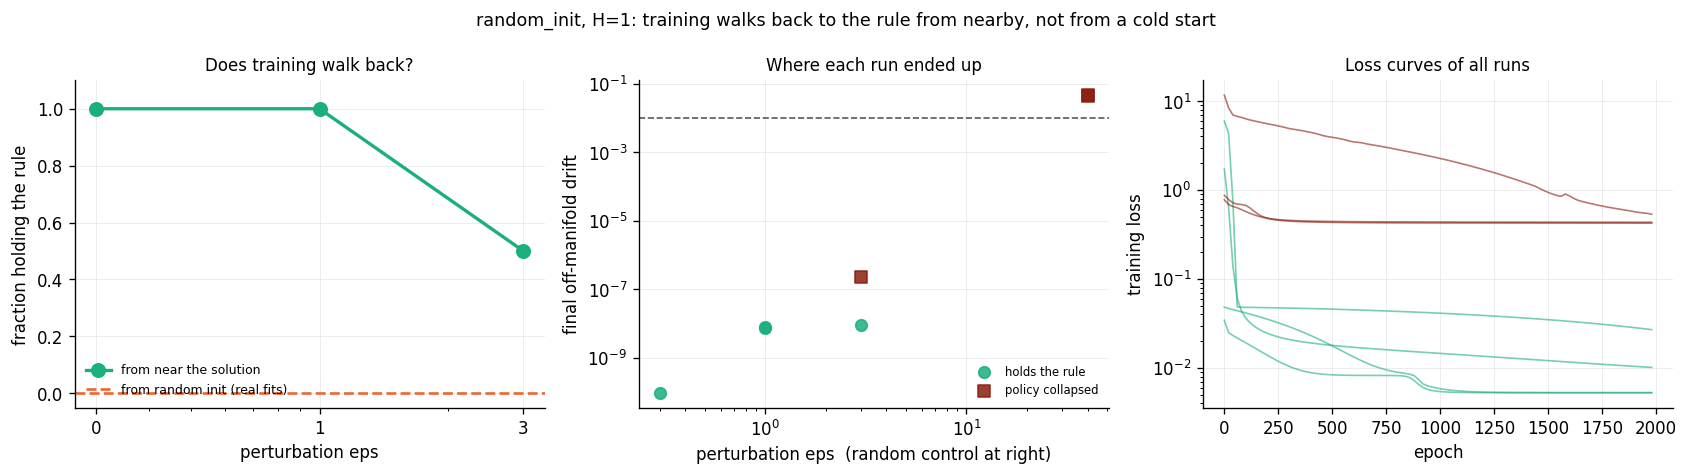

In [18]:
# --- 5.7 the basin of attraction: does training walk back? (reduced, cached) ----------------
EPS_LADDER, BASIN_SEEDS, N_RANDOM = [0.0, 1.0, 3.0], [0, 1], 2
_sig57 = dict(dataset=DATASET, H=HINV, epochs=EPOCHS_INV, eps=list(EPS_LADDER),
              seeds=list(BASIN_SEEDS), nrand=N_RANDOM, probe="winstay-v4")
_cache57 = os.path.join(INV_DIR, f"basin_H{HINV}.pkl")

def _run_basin():
    out = []
    for eps in EPS_LADDER:
        for sd in (BASIN_SEEDS if eps > 0 else [0]):
            P0 = SOLVED[HINV] if eps == 0 else perturb(SOLVED[HINV], eps, sd)
            P1, curve, _ = train_tracked(P0, epochs=EPOCHS_INV, seed=sd, every=EPOCHS_INV, l1w=0.0)
            a, d, _ = verdict(P1)
            out.append(dict(kind="perturbed", eps=eps, acc=a, drift=d, curve=curve[::20].astype("float32")))
    for sd in range(N_RANDOM):
        P1, curve, _ = train_tracked(random_start(1000 + sd), epochs=EPOCHS_INV, seed=sd, every=EPOCHS_INV, l1w=0.0)
        a, d, _ = verdict(P1)
        out.append(dict(kind="random", eps=None, acc=a, drift=d, curve=curve[::20].astype("float32")))
    return out

BASIN = _load_or_run(_cache57, _sig57, _run_basin, "the reduced basin ladder")

def _held(r): return learned_policy(r["acc"]) and r["drift"] < DRIFT_TOL
def _outcome(r):
    if not learned_policy(r["acc"]): return "collapsed"
    return "holds" if r["drift"] < DRIFT_TOL else "drifted"
pert = [r for r in BASIN if r["kind"] == "perturbed"]; rand = [r for r in BASIN if r["kind"] == "random"]

print(f"\nbest achievable accuracy (the FSC's own): {FSC_ACC:.4f}\n")
print(f"{'start':>24}  {'runs':>5}  {'mean acc':>9}  {'mean drift':>11}  {'fraction holding rule':>21}")
for eps in EPS_LADDER:
    rs = [r for r in pert if r["eps"] == eps]
    print(f"{('exact + noise eps=' + format(eps, 'g')):>24}  {len(rs):>5}  {np.mean([r['acc'] for r in rs]):>9.4f}  "
          f"{np.mean([r['drift'] for r in rs]):>11.1e}  {np.mean([_held(r) for r in rs]):>21.2f}")
print(f"{'random init (real fits)':>24}  {len(rand):>5}  {np.mean([r['acc'] for r in rand]):>9.4f}  "
      f"{np.mean([r['drift'] for r in rand]):>11.1e}  {np.mean([_held(r) for r in rand]):>21.2f}")

_STY = {"holds":     dict(c=C_SOLVED,  m="o", lbl="holds the rule"),
        "drifted":   dict(c=C_TRAINED, m="X", lbl="predicts the data, breaks the rule"),
        "collapsed": dict(c="#8a1f0f", m="s", lbl="policy collapsed")}
_pos = lambda e: (0.3 if (e is None or e == 0) else e)
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.0))

ax = axes[0]
fr = [((e if e > 0 else 0.3), np.mean([_held(r) for r in pert if r["eps"] == e])) for e in EPS_LADDER]
ax.plot([x for x, _ in fr], [f for _, f in fr], "o-", color=C_SOLVED, lw=2.0, ms=8, label="from near the solution")
ax.axhline(np.mean([_held(r) for r in rand]), color=C_TRAINED, ls="--", lw=1.6, label="from random init (real fits)")
ax.set_xscale("log"); ax.set_xticks([0.3] + [e for e in EPS_LADDER if e > 0])
ax.set_xticklabels(["0"] + [f"{e:g}" for e in EPS_LADDER if e > 0])
ax.set_xlabel("perturbation eps"); ax.set_ylabel("fraction holding the rule"); ax.set_ylim(-0.05, 1.1)
ax.set_title("Does training walk back?", fontsize=10); ax.legend(fontsize=7.5, loc="lower left")

ax = axes[1]; _seen = set()
for r in BASIN:
    st = _STY[_outcome(r)]; x = 40 if r["kind"] == "random" else _pos(r["eps"])
    lbl = st["lbl"] if st["lbl"] not in _seen else None; _seen.add(st["lbl"])
    ax.scatter(x, max(r["drift"], 1e-12), color=st["c"], marker=st["m"], s=48, alpha=0.85, zorder=3, label=lbl)
ax.axhline(DRIFT_TOL, color=C_RULE, ls="--", lw=1.0)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("perturbation eps  (random control at right)"); ax.set_ylabel("final off-manifold drift")
ax.set_title("Where each run ended up", fontsize=10); ax.legend(fontsize=7, loc="lower right")

ax = axes[2]
for r in BASIN:
    ax.plot(np.arange(len(r["curve"])) * 20, r["curve"], color=_STY[_outcome(r)]["c"], lw=1.0, alpha=0.6)
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("training loss")
ax.set_title("Loss curves of all runs", fontsize=10)
fig.suptitle(f"{DATASET}, H={HINV}: training walks back to the rule from nearby, not from a cold start",
             fontsize=10.5)
plt.tight_layout(); plt.show()

### 5.8 The answer: representable is not reachable

Putting section 5 together:

1. **The trained GRU learns the policy on the data** (section 4), but its hidden state drifts once an
   input repeats past what the data showed (section 5.4). The loss is blind to that region, so nothing
   constrains it there.

2. **An exact GRU that *is* the controller exists** wherever the hidden size is large enough to hold the
   memory states (section 5.2), and that includes surprisingly small sizes: a single unit can place
   several states on a line with the right gating.

3. **But training does not find it, and sometimes cannot even keep it.** From a cold start it is never
   reached: cross-entropy has no gradient off-manifold, so the exact rule is one of infinitely many
   networks that fit the data equally and nothing selects it. Started *at* the exact weights, whether
   training holds them depends on the task and size (section 5.6): on the win-stay/lose-shift tasks the
   exact solution is a resting point that L1=0 holds and the L1 penalty erodes, while at the smallest
   size on the 3-state task it is a saddle that even L1=0 slides off. Training walks back to it only from
   a start already close by (section 5.7).

So "small enough to represent the controller" and "reachable by training" are different properties, and
they come apart most sharply at the smallest size that still works. To actually obtain the exact
controller you have to change the problem: initialise near the solution, add data that exercises the
off-manifold behavior, or construct the weights directly as section 5.2 does.

## 6. The two internal states line up

The payoff. On the data, the trained GRU's hidden state carries the same memory the FSC does. We
show it three ways at the size where the hidden state is a single number (H=1): the two trajectories
tracking each other along a session, the hidden value falling into two tight groups labelled by the
FSC state, and, at H=2, the same separation in the network's own state space.

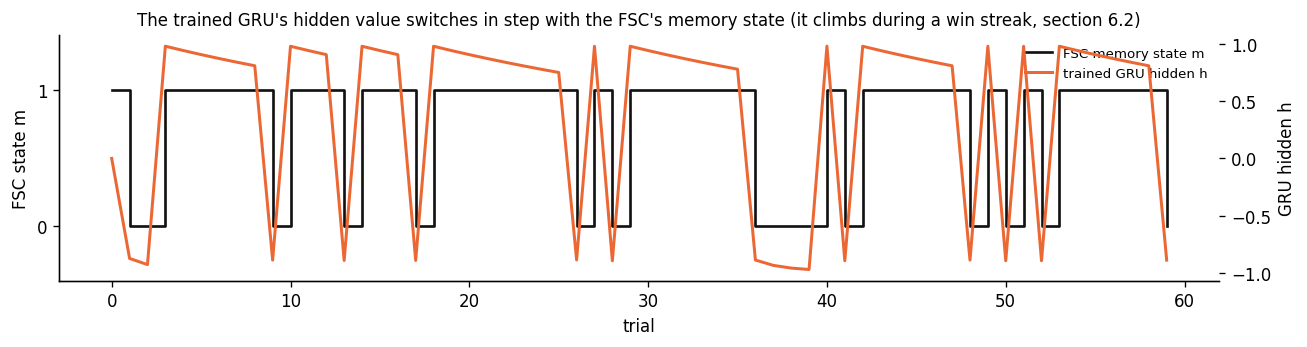

In [19]:
# --- 6.1 belief and hidden state, tracking each other along one session ----------------------
P1 = TRAINED[H_STAR]
s = TEST_SESS[0]
b = fsc_beliefs(FSC, s["actions"], s["observations"])
h = rnn_states(P1, s["actions"], s["observations"], A, Y)[:, 0]   # H=1: hidden is a scalar
m_seq = b.argmax(1)
Tshow = 60
fig, ax = plt.subplots(figsize=(11.0, 3.0))
ax.step(np.arange(Tshow), m_seq[:Tshow], where="post", color=C_FSC, lw=1.6,
        label="FSC memory state m")
ax2 = ax.twinx()
ax2.plot(np.arange(Tshow), h[:Tshow], color=C_TRAINED, lw=1.8, label="trained GRU hidden h")
ax.set_yticks(range(M)); ax.set_ylabel("FSC state m"); ax.set_ylim(-0.4, M - 0.6)
ax2.set_ylabel("GRU hidden h"); ax.set_xlabel("trial")
ax.grid(False); ax2.grid(False)
l1, la1 = ax.get_legend_handles_labels(); l2, la2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, la1 + la2, fontsize=8, loc="upper right")
ax.set_title("The trained GRU's hidden value switches in step with the FSC's memory state "
             "(it climbs during a win streak, section 6.2)", fontsize=10)
plt.tight_layout(); plt.show()

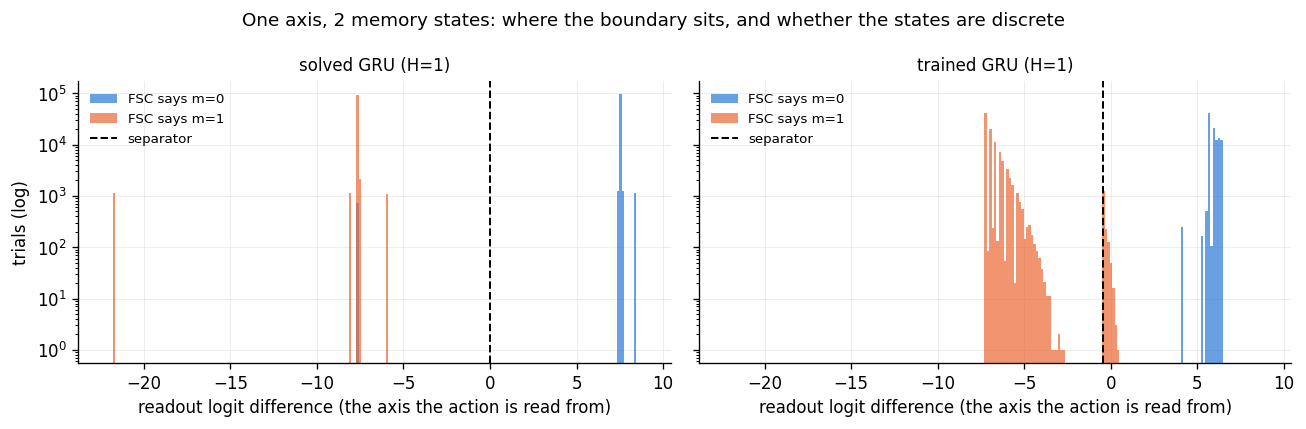

  solved: nearest-state-median on the readout axis recovers the FSC state  99.63% of trials;  separator(s) at [0.0];  widest within-state spread 15.985
 trained: nearest-state-median on the readout axis recovers the FSC state  99.17% of trials;  separator(s) at [-0.454];  widest within-state spread 7.589

The FSC's memory is linearly readable from the GRU on the action axis, and the black dashed line(s)
are the decision boundary between adjacent states: cross one and the readout flips to the next state's
action. The solved network puts each state at a point; the trained network smears each into a band,
which is the same off-manifold looseness section 5.4 measured. Same states, sharper for the solve.


In [20]:
# --- 6.2 the hidden state, read on the action axis, falls into one group per FSC state --------
# Project every hidden state onto the readout logit difference d = (lin_W0 - lin_W1) . h + b, the
# 1-D quantity the action is actually read from. This works at any hidden size (for H=1 it is affine
# in h) and any number of memory states, so it also shows WHERE the boundary between states sits.
def logit_vals(P, sessions):
    w = P["lin_W"][0] - P["lin_W"][1]; b = P["lin_b"][0] - P["lin_b"][1]; out = []
    for s in sessions:
        for h in rnn_states(P, s["actions"], s["observations"], A, Y)[:-1]:
            out.append(float(w @ np.atleast_1d(h) + b))
    return np.array(out)
def fsc_labels(sessions):
    return np.concatenate([fsc_beliefs(FSC, s["actions"], s["observations"])[:-1].argmax(1) for s in sessions])

LAB   = fsc_labels(SESS)
D_sol = logit_vals(SOLVED[H_STAR], SESS)
D_tr  = logit_vals(TRAINED[H_STAR], SESS)

def separators(vals, lab):
    """Midpoints between adjacent FSC-state medians on the axis: the decision boundaries."""
    meds = sorted((float(np.median(vals[lab == m])), m) for m in range(M) if (lab == m).any())
    return [0.5 * (meds[i][0] + meds[i + 1][0]) for i in range(len(meds) - 1)]
def recover_acc(vals, lab):
    """Nearest-state-median classifier accuracy on the axis (generalises a single threshold)."""
    meds = np.array([np.median(vals[lab == m]) if (lab == m).any() else np.inf for m in range(M)])
    return (np.argmin(np.abs(vals[:, None] - meds[None, :]), axis=1) == lab).mean()

_bins = np.linspace(min(D_sol.min(), D_tr.min()) - 0.5, max(D_sol.max(), D_tr.max()) + 0.5, 220)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.6), sharey=True)
for ax, (Dv, nm) in zip(axes, [(D_sol, f"solved GRU (H={H_STAR})"), (D_tr, f"trained GRU (H={H_STAR})")]):
    for m in range(M):
        if (LAB == m).any():
            ax.hist(Dv[LAB == m], bins=_bins, color=C_STATE[m], alpha=0.7, label=f"FSC says m={m}")
    for i, x in enumerate(separators(Dv, LAB)):
        ax.axvline(x, color="k", ls="--", lw=1.2, label="separator" if i == 0 else None)
    ax.set_yscale("log"); ax.set_xlabel("readout logit difference (the axis the action is read from)")
    ax.set_title(nm, fontsize=10); ax.legend(fontsize=8)
axes[0].set_ylabel("trials (log)")
fig.suptitle(f"One axis, {M} memory states: where the boundary sits, and whether the states are discrete",
             fontsize=11)
plt.tight_layout(); plt.show()

for Dv, nm in [(D_sol, "solved"), (D_tr, "trained")]:
    acc = recover_acc(Dv, LAB); seps = separators(Dv, LAB)
    spread = max(np.ptp(Dv[LAB == m]) for m in range(M) if (LAB == m).any())
    print(f"{nm:>8}: nearest-state-median on the readout axis recovers the FSC state {acc*100:6.2f}% of "
          f"trials;  separator(s) at {[round(x, 3) for x in seps]};  widest within-state spread {spread:.3f}")
print("\nThe FSC's memory is linearly readable from the GRU on the action axis, and the black dashed line(s)")
print("are the decision boundary between adjacent states: cross one and the readout flips to the next state's")
print("action. The solved network puts each state at a point; the trained network smears each into a band,")
print("which is the same off-manifold looseness section 5.4 measured. Same states, sharper for the solve.")

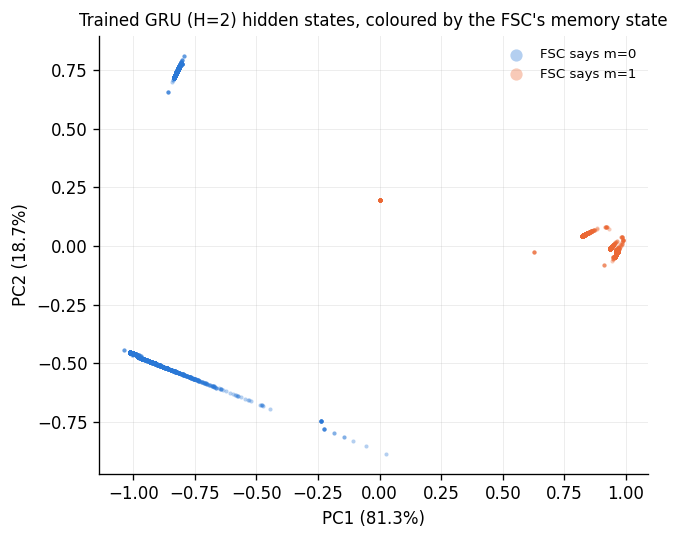

PC1 carries 81.3% of the variance and separates the two
FSC states cleanly: they sit at opposite ends of one direction, the same picture as H=1. The
remaining 18.7% is within-state structure (the win-state
still ramps with streak length). Decoding what that structure encodes is the follow-on notebook.


In [21]:
# --- 6.3 the same separation at H=2, in the network's own state space -------------------------
if 2 in TRAINED:
    from sklearn.decomposition import PCA
    def hidden_cloud(P, sessions):
        rows = []
        for s in sessions:
            hh = rnn_states(P, s["actions"], s["observations"], A, Y)[:-1]; rows.append(hh)
        return np.concatenate(rows)
    Xc = hidden_cloud(TRAINED[2], SESS); lab = fsc_labels(SESS)
    with quiet_blas():
        p = PCA().fit(Xc); Z = p.transform(Xc)
    rng = np.random.default_rng(0); sub = rng.choice(len(Z), min(6000, len(Z)), replace=False)
    fig, ax = plt.subplots(figsize=(5.6, 4.6))
    for m in range(M):
        k = lab[sub] == m
        ax.scatter(Z[sub][k, 0], Z[sub][k, 1], s=6, alpha=0.35, color=C_STATE[m],
                   lw=0, label=f"FSC says m={m}")
    # the solved embedding, projected into the trained network's PCA frame, as anchors
    ax.set_xlabel(f"PC1 ({p.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({p.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend(fontsize=8, markerscale=3)
    ax.set_title("Trained GRU (H=2) hidden states, coloured by the FSC's memory state", fontsize=10)
    plt.tight_layout(); plt.show()
    print(f"PC1 carries {p.explained_variance_ratio_[0]*100:.1f}% of the variance and separates the two")
    print("FSC states cleanly: they sit at opposite ends of one direction, the same picture as H=1. The")
    print(f"remaining {(1-p.explained_variance_ratio_[0])*100:.1f}% is within-state structure (the win-state")
    print("still ramps with streak length). Decoding what that structure encodes is the follow-on notebook.")

## 7. What we found

Running the whole pipeline:

1. **Both models fit the behavior.** The FSC selects its memory states by held-out loss (section 2),
   and the trained GRUs match it on held-out likelihood and on the full action-transition matrix
   (section 4). By the standard measurements the GRU learned the policy.

2. **An exact GRU that *is* the FSC exists** where the hidden size is large enough: solving rather than
   training gives weights whose one-step map lands on the controller's memory states to under 1e-8
   (section 5.2). A size too small to hold every state shows up there as a solve that never reaches zero.

3. **The trained GRU does not become that exact GRU, and section 5 says why.** It is not an L1 problem
   and no epoch budget fixes it. The data holds no repeated input past the longest run it contains, so
   cross-entropy has no gradient off-manifold: the exact rule is one of infinitely many networks that fit
   the data equally, and nothing selects it. Trained *at* the exact weights with L1=0 the rule holds;
   with L1=1e-5 the penalty erodes it; from a cold start it is never found (the network learns the policy
   but drifts, or collapses). Training walks back to the rule only from near it (section 5.7). To get the
   exact controller you must change the problem: seed near the solution, add off-manifold data, or
   construct it directly.

4. **The two internal states still line up.** On the data the trained GRU's hidden state carries the same
   memory as the FSC: a threshold or linear map recovers the FSC state, and the states separate in state
   space (section 6). The geometry is not identical: the FSC keeps discrete points, the trained GRU
   spreads a state into a graded ramp.

To run this on another dataset, change `DATASET` in section 0 and rerun: every figure and table
regenerates for the chosen task. The shipped datasets are `random_init` and `det_init` (2-state
win-stay/lose-shift, random vs fixed start) and `ts` (a 3-state task).